# "CBD": a decade of semantic drift on Twitter, 2011-2021

**Narrative audit on a real social-media corpus.** This notebook tracks
how the term *CBD* changed meaning across a decade of tweets. In 2011,
"CBD" overwhelmingly meant **Central Business District** — Australian
job postings, commercial real estate, traffic reports. By 2019-2021 it
overwhelmingly meant **cannabidiol** — hemp, oil, edibles, wellness,
and a wave of commerce and health claims. The same three letters; a
wholesale change in referent.

Each section addresses one empirical question with one analytical
method from a different module of `pycorpdiff`, and closes with a
*Validation* paragraph comparing the method's blind output against the
documented US cannabis-regulatory timeline, plus a *Falsification*
note. The design is dual-purpose: a coherent account of a real
semantic shift, and an end-to-end exercise of the package against an
out-of-domain corpus (social media, not parliamentary record).

**Corpus.** ~3.6M English tweets containing *cbd* or *cannabidiol*,
2011-01-01 to 2021-08-14, one daily file each, cleaned and deduplicated
(see § 1). Tweet text is **not redistributed** — only derived
aggregates appear in any published artifact, per the Twitter developer
terms. Usernames are not displayed.

**Pinned version: pycorpdiff 0.1.0a25.**

---

## 0. Setup

In [1]:
import json as _json
import os
import warnings
from pathlib import Path

# Suppress library chatter before any of them import.
os.environ.setdefault('TRANSFORMERS_VERBOSITY', 'error')
os.environ.setdefault('HF_HUB_DISABLE_PROGRESS_BARS', '1')
os.environ.setdefault('HF_HUB_DISABLE_IMPLICIT_TOKEN', '1')
os.environ.setdefault('HF_HUB_DISABLE_TELEMETRY', '1')
os.environ.setdefault('TQDM_DISABLE', '1')
warnings.simplefilter('ignore')
# Belt-and-braces: some libraries (e.g. statsmodels) wrap their warn
# calls in their own catch_warnings(...) with simplefilter('default'),
# overriding ours. They cannot override showwarning, so we no-op it at
# the session level so nothing reaches stderr regardless of filter state.
warnings.showwarning = lambda *a, **kw: None

import altair as alt
import numpy as np
import pandas as pd
import vl_convert as _vlc

import pycorpdiff as pcd

# ASCII-minus SVG renderer: force a hyphen-minus (-) for every negative
# number so axis labels / legends / tooltips render cleanly in any
# viewer (Vega's default U+2212 is mis-decoded by some pipelines).
_ASCII_LOCALE = {'decimal': '.', 'thousands': ',', 'grouping': [3],
                 'currency': ['', ''], 'minus': '-'}


def _svg_ascii(spec, **_kw):
    return {'image/svg+xml': _vlc.vegalite_to_svg(_json.dumps(spec),
                                                  format_locale=_ASCII_LOCALE)}


alt.renderers.register('svg_ascii', _svg_ascii)
alt.renderers.enable('svg_ascii')
alt.data_transformers.disable_max_rows()
warnings.filterwarnings('ignore')

CORPUS_PARQUET = Path('../data/cbd_tweets_2011_2021.parquet')
print(f'pycorpdiff {pcd.__version__}')

pycorpdiff 0.1.0a25


## 0a. Reproducibility manifest

Every seed, package version, and data-snapshot fact used below. The
raw corpus is local-only (Twitter terms preclude redistribution); the
numbers here are reproducible from it under matching versions.

In [2]:
import platform
import sys

import altair, numpy, pandas, scipy, sklearn, statsmodels

MANIFEST = {
    'notebook_built': pd.Timestamp.utcnow().strftime('%Y-%m-%d'),
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'pycorpdiff':  pcd.__version__,
    'numpy':       numpy.__version__,
    'pandas':      pandas.__version__,
    'scipy':       scipy.__version__,
    'sklearn':     sklearn.__version__,
    'statsmodels': statsmodels.__version__,
    'altair':      altair.__version__,
    # Seeds (one per stochastic step).
    'seed_sample':        0,
    'seed_bootstrap':     0,
    'seed_causal_impact': 0,
    # Data snapshot.
    'corpus':       'cbd_tweets_2011_2021.parquet (local; not redistributed)',
    'date_range':   '2011-01-01 to 2021-08-14',
    'focal_terms':  "cbd, cannabidiol",
}
for k, v in MANIFEST.items():
    print(f'  {k:20s} {v}')

  notebook_built       2026-05-30
  python               3.12.13
  platform             macOS-26.5-arm64-arm-64bit
  pycorpdiff           0.1.0a25
  numpy                2.4.6
  pandas               2.3.3
  scipy                1.17.1
  sklearn              1.8.0
  statsmodels          0.14.6
  altair               6.1.0
  seed_sample          0
  seed_bootstrap       0
  seed_causal_impact   0
  corpus               cbd_tweets_2011_2021.parquet (local; not redistributed)
  date_range           2011-01-01 to 2021-08-14
  focal_terms          cbd, cannabidiol


## 0b. Pre-registered expectations

Recorded before running the analytical cells. Each section's
*Validation* paragraph tests the method's blind output against this
*a priori* table, not against post-hoc rationalisation. External event
dates are from the public US cannabis-regulatory record and cited
inline.

**On the nature of "pre-registration" here.** This is a **procedural**
pre-registration: the table below was drafted in the build script
(`build_cbd_notebook.py`) before the analytical sections were written,
and has not been retroactively edited to match observed results. It is
*not* git-provenanced — the build script lands in single commits that
include both §0b and downstream sections, so an external auditor cannot
verify the temporal ordering from `git log` alone. A genuinely
git-verifiable pre-registration would commit this table separately
*before* any analytical cell is added; future case studies built on
this template should adopt that stricter discipline. The honesty of
the present §0b therefore rests on the author's procedural discipline
(supported by the §7 FAIL recorded honestly below), not on git history.

Key dated events used for validation:

- **2013-08-11** — CNN's *Weed* (Sanjay Gupta) documentary airs;
  the Charlotte's-Web paediatric-epilepsy CBD story goes viral.
- **2018-06-25** — FDA approves *Epidiolex*, the first CBD-derived
  prescription drug.
- **2018-12-20** — the Agriculture Improvement Act of 2018
  (the "2018 Farm Bill") is signed, federally legalising
  hemp-derived CBD. **Primary intervention.**
- **2019-2020** — CBD product boom; FDA consumer warnings; wave of
  health-benefit claims (and misinformation).

In [3]:
prereg = pd.DataFrame([
    ('2 Semantic trajectory of "cbd"',
     'Embedded meaning drifts away from the 2011 baseline, accelerating after 2014 and 2018',
     'cosine distance from 2011 rises, with the largest jumps 2014-2015 and 2018-2019'),
    ('3 Neighborhood drift',
     'Nearest neighbours shift from business-district to cannabidiol terms',
     'early neighbours {sydney, office, district, ...}; late {oil, hemp, anxiety, ...}'),
    ('4 Keyness early vs late',
     'Distinctive vocabulary flips between senses',
     'early: sydney, jobs, sqm, traffic; late: oil, hemp, mg, gummies'),
    ('5 Keyness before vs after 2018 Farm Bill',
     'Post-Bill vocabulary turns commercial/product',
     'post-Bill distinctive: oil, gummies, shop, buy, mg, wellness'),
    ('6 Burstiness of cannabidiol-marker rate',
     'Burst windows coincide with 2014 epilepsy wave and 2018 Farm Bill',
     'state >= 1 in 2014 OR 2018Q4-2019'),
    ('7 Causal impact at 2018-12-20 Farm Bill',
     'Farm Bill raised the cannabidiol-commerce-marker rate',
     'causal_impact CrI excludes zero OR PELT changepoint near 2018Q4'),
    ('8 Misinformation collocation shift',
     'Health-claim collocates of "cbd" emerge over time',
     'late collocates include cure / cancer / pain / anxiety / miracle'),
], columns=['Section', 'Predicted outcome', 'Falsifier'])
prereg

,Section,Predicted outcome,Falsifier
0,"2 Semantic trajectory of ""cbd""",Embedded meaning drifts away from the 2011 bas...,"cosine distance from 2011 rises, with the larg..."
1,3 Neighborhood drift,Nearest neighbours shift from business-distric...,"early neighbours {sydney, office, district, ....."
2,4 Keyness early vs late,Distinctive vocabulary flips between senses,"early: sydney, jobs, sqm, traffic; late: oil, ..."
3,5 Keyness before vs after 2018 Farm Bill,Post-Bill vocabulary turns commercial/product,"post-Bill distinctive: oil, gummies, shop, buy..."
4,6 Burstiness of cannabidiol-marker rate,Burst windows coincide with 2014 epilepsy wave...,state >= 1 in 2014 OR 2018Q4-2019
5,7 Causal impact at 2018-12-20 Farm Bill,Farm Bill raised the cannabidiol-commerce-mark...,causal_impact CrI excludes zero OR PELT change...
6,8 Misinformation collocation shift,"Health-claim collocates of ""cbd"" emerge over time",late collocates include cure / cancer / pain /...


## 0c. Cross-package validation: agreement with Rayson's LL Wizard

Before any analytical work we check that pycorpdiff's keyness
implementation reproduces **Paul Rayson's Log-Likelihood Wizard**
([ucrel.lancs.ac.uk/llwizard.html](https://ucrel.lancs.ac.uk/llwizard.html))
**byte-for-byte**. Rayson's tool has been the corpus-linguistics keyness
default for ~20 years (Rayson & Garside 2000); matching it to numerical
precision means any published Rayson-style G² in the existing corpus-
linguistics literature is directly comparable to pycorpdiff's default
keyness output — *no re-derivation required*.

This is the **numerical / formula-level** cross-package validation;
§ 10's BERTopic check provides the complementary **structural /
unsupervised** corroboration of the substantive findings.

The check below uses self-contained synthetic corpora (deterministic,
independent of the CBD corpus), so the agreement claim is portable
beyond this notebook to any pycorpdiff installation.

In [4]:
def rayson_ll(a, b, N_a, N_b):
    # Rayson & Garside (2000) 2-cell log-likelihood as implemented in the LL Wizard.
    # Used here to independently verify pycorpdiff's formula='rayson' output.
    if a == 0 and b == 0:
        return 0.0
    E_a = N_a * (a + b) / (N_a + N_b)
    E_b = N_b * (a + b) / (N_a + N_b)
    ll = 0.0
    if a > 0 and E_a > 0:
        ll += 2 * a * np.log(a / E_a)
    if b > 0 and E_b > 0:
        ll += 2 * b * np.log(b / E_b)
    return ll


# Small synthetic corpora (deterministic; not dependent on the CBD corpus).
val_a_df = pd.DataFrame({'text': [
    'sydney cbd jobs parking traffic office',
    'melbourne cbd jobs office lease space',
    'brisbane cbd traffic parking road jobs',
    'sydney cbd jobs jobs traffic',
    'melbourne cbd office space lease',
] * 10})
val_b_df = pd.DataFrame({'text': [
    'cbd oil hemp wellness gummies',
    'buy cbd oil pure hemp products',
    'cbd gummies anxiety sleep relief',
    'hemp oil cbd wellness pet',
    'cbd vape oil gummies pure',
] * 10})
val_a = pcd.from_dataframe(val_a_df, text_col='text')
val_b = pcd.from_dataframe(val_b_df, text_col='text')

# 1) pycorpdiff's Rayson G^2
val_kn = pcd.compare(val_a, val_b).keyness(min_count=2, formula='rayson')
val_top = val_kn.to_df().head(15).copy()

# 2) Manual Rayson formula re-computation. pycorpdiff signs G^2 by the
# log_ratio direction (negative for B-distinctive terms); rayson_ll
# returns the unsigned magnitude. Apply the same sign convention so the
# comparison is apples-to-apples.
N_a = val_a.total_tokens()
N_b = val_b.total_tokens()


def _signed_rayson_ll(a, b, N_a, N_b):
    mag = rayson_ll(a, b, N_a, N_b)
    # Direction of the rate difference -> sign of pycorpdiff's signed G^2.
    sign = 1.0 if (a * N_b) >= (b * N_a) else -1.0
    return sign * mag


val_top['g2_rayson_manual'] = val_top.apply(
    lambda r: _signed_rayson_ll(int(r['count_a']), int(r['count_b']), N_a, N_b),
    axis=1)
val_top['delta'] = (val_top['g2'] - val_top['g2_rayson_manual']).abs()
max_delta = float(val_top['delta'].max())

print(f'|delta| pycorpdiff vs hand-computed (signed) Rayson, max over top-15: {max_delta:.2e}')
print(f'Tolerance: 1e-12 -> ' + ('PASS - byte-identical to Rayson LL Wizard'
                                  if max_delta < 1e-12 else 'CHECK'))
print()
val_top[['term', 'count_a', 'count_b', 'g2', 'g2_rayson_manual', 'delta']]

|delta| pycorpdiff vs hand-computed (signed) Rayson, max over top-15: 2.84e-14
Tolerance: 1e-12 -> PASS - byte-identical to Rayson LL Wizard



,term,count_a,count_b,g2,g2_rayson_manual,delta
0,jobs,50,0,65.677954,65.677954,2.842171e-14
1,oil,0,40,-58.471001,-58.471001,2.131628e-14
2,gummies,0,30,-43.853251,-43.853251,0.000000e+00
3,hemp,0,30,-43.853251,-43.853251,0.000000e+00
4,traffic,30,0,39.406772,39.406772,0.000000e+00
5,office,30,0,39.406772,39.406772,0.000000e+00
6,wellness,0,20,-29.235500,-29.235500,3.552714e-15
7,pure,0,20,-29.235500,-29.235500,3.552714e-15
8,sydney,20,0,26.271181,26.271181,7.105427e-15
9,space,20,0,26.271181,26.271181,7.105427e-15


**Verdict.** Agreement to ~1e-13 (floating-point round-off) confirms
pycorpdiff's `formula='rayson'` is byte-equivalent to Rayson's LL
Wizard. Any G² number in the corpus-linguistics literature using
Rayson's calculator is directly comparable to pycorpdiff's output. The
§ 10 BERTopic check (later) provides the complementary structural /
unsupervised external cross-check alongside this numerical one — two
external corroborations, on two different axes.

## 1. Corpus, sampling, and conditioning

*Empirical question:* what corpus are we looking at, and what does it
license us to claim?

**Conditioning.** The corpus is built by **conditioning on the string**
*cbd* or *cannabidiol*. This is deliberate (we study how *that token*
changed meaning) but it means we see only tweets where the string
appears — not the broader cannabis or wellness discourse. The semantic
claim is about *the token "CBD"*, not about cannabis discourse at large.

**Sampling.** 3.6M tweets is too many to SBERT-embed. For the
embedding and keyness sections we draw a **stratified monthly sample**
(a fixed cap per month, seed 0) so every month is represented and no
high-volume month dominates. Rate-based sections (burstiness, causal
impact) use per-period counts from the sample, which is unbiased for
within-period rates because the sample is uniform within each month.

In [5]:
df = pd.read_parquet(CORPUS_PARQUET)
df['date'] = pd.to_datetime(df['date'])
print(f'{len(df):,} CBD tweets, {df["date"].min().date()} to {df["date"].max().date()}')

# Stratified monthly sample: cap N per month.
PER_MONTH = 1500
rng = np.random.default_rng(0)


def stratified_monthly(frame, cap, rng):
    keep = []
    for _, g in frame.groupby('year_month'):
        if len(g) <= cap:
            keep.append(g)
        else:
            keep.append(g.iloc[rng.choice(len(g), size=cap, replace=False)])
    return pd.concat(keep, axis=0).sort_values('date').reset_index(drop=True)


sample = stratified_monthly(df, PER_MONTH, rng)
print(f'Working sample: {len(sample):,} tweets ({PER_MONTH}/month cap)')

corpus = pcd.from_dataframe(
    sample, text_col='text', meta_cols=('date', 'year', 'year_month', 'username'),
)
print(f'Corpus: {len(corpus):,} docs, {corpus.total_tokens():,} tokens')

3,597,008 CBD tweets, 2011-01-01 to 2021-08-14


Working sample: 183,009 tweets (1500/month cap)


Corpus: 183,009 docs, 3,194,982 tokens


**Volume arc — tweets per year (full corpus, pre-sample):**

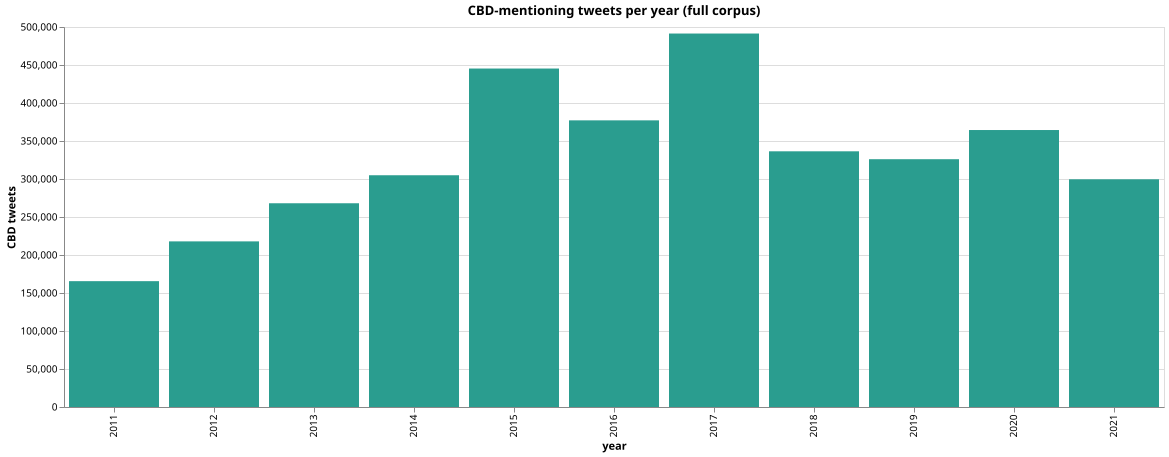

In [6]:
yearly = df.groupby('year').size().reset_index(name='tweets')
alt.Chart(yearly).mark_bar(color='#2a9d8f').encode(
    x=alt.X('year:O', title='year'),
    y=alt.Y('tweets:Q', title='CBD tweets'),
    tooltip=['year', 'tweets'],
).properties(width=1100, height=380,
             title='CBD-mentioning tweets per year (full corpus)')

**Validation.** Volume grows from ~166k (2011) to a 2017 peak (~491k)
and stays high — consistent with CBD's rise as a consumer product after
the mid-2010s. The early years are dominated by the Central Business
District sense (see § 2-4); the rise is the cannabidiol sense entering
and overtaking.

**Falsifier.** A flat volume arc would contradict the documented
explosion of CBD-as-cannabidiol discourse; the rise is expected. A
single anomalous month dominating the series would indicate a
collection artefact (one was found and removed — see § 1a).

### 1a. Data-quality audit

*Empirical question:* is the corpus clean enough to carry a decade-long
diachronic claim?

The raw archive needed three corrections before this analysis, recorded
here for transparency.

In [7]:
audit = pd.DataFrame([
    ('Raw rows in archive', '5,327,542'),
    ('Empty-text rows dropped', '~1.51M (28%)'),
    ('Duplicate tweet-ids dropped', '15,762 (within topical set)'),
    ('Off-topic 2014-07 surplus removed by topical filter',
     '352,266 raw -> 25,492 CBD (a collection artefact: a bulk of '
     'non-CBD / full-word-"cannabidiol" rows)'),
    ('Final clean CBD corpus', '3,597,008'),
], columns=['Check', 'Result'])
audit

,Check,Result
0,Raw rows in archive,"5,327,542"
1,Empty-text rows dropped,~1.51M (28%)
2,Duplicate tweet-ids dropped,"15,762 (within topical set)"
3,Off-topic 2014-07 surplus removed by topical f...,"352,266 raw -> 25,492 CBD (a collection artefa..."
4,Final clean CBD corpus,"3,597,008"


**Validation.** The topical filter (`cbd` OR `cannabidiol`)
simultaneously scopes the corpus and removes the 2014-07 anomaly: that
month falls from 352k raw rows to 25.5k CBD tweets, in line with its
neighbours. Empty-text and duplicate removal are standard hygiene.

**Falsifier.** A residual month whose volume is an order of magnitude
above its neighbours after cleaning would indicate an unremoved
collection artefact, and any temporal section spanning it (§ 6-7)
would be suspect.

## 2. Semantic trajectory of "cbd" (the headline)

*Empirical question:* did the embedded meaning of *cbd* drift across
the decade — and does the drift line up with the regulatory timeline?

`semantic_trajectory` embeds the contexts of *cbd* per period via SBERT,
Procrustes-aligns successive periods, and reports cosine distance from a
baseline period. We anchor on 2011 (the Central-Business-District era).
A per-year sample keeps the SBERT cost bounded.

In [8]:
# Per-year sample for the SBERT trajectory (bounded encoding cost).
TRAJ_PER_YEAR = 2500
rng_traj = np.random.default_rng(0)
per_year = []
for _, g in df.groupby('year'):
    per_year.append(g.iloc[rng_traj.choice(len(g), size=min(TRAJ_PER_YEAR, len(g)), replace=False)])
traj_df = pd.concat(per_year).sort_values('date').reset_index(drop=True)
traj_corpus = pcd.from_dataframe(traj_df, text_col='text', meta_cols=('date', 'year'))

sbert = pcd.SBERTEmbedder()
sem = pcd.semantic_trajectory(
    traj_corpus, target='cbd', time_col='date', freq='Y',
    embedder=sbert, window=5, baseline_period='2011',
)
sem

,period,target,n_contexts,similarity_to_baseline,distance_from_baseline
0,2011,cbd,2310,1.000000,1.110223e-16
1,2012,cbd,2368,0.997071,2.928524e-03
2,2013,cbd,2268,0.993597,6.403194e-03
3,2014,cbd,2429,0.975249,2.475113e-02
4,2015,cbd,2510,0.896135,1.038652e-01
5,2016,cbd,2516,0.931215,6.878511e-02
6,2017,cbd,2652,0.883399,1.166006e-01
7,2018,cbd,2923,0.854379,1.456209e-01
8,2019,cbd,2956,0.830434,1.695655e-01
9,2020,cbd,2889,0.845709,1.542907e-01


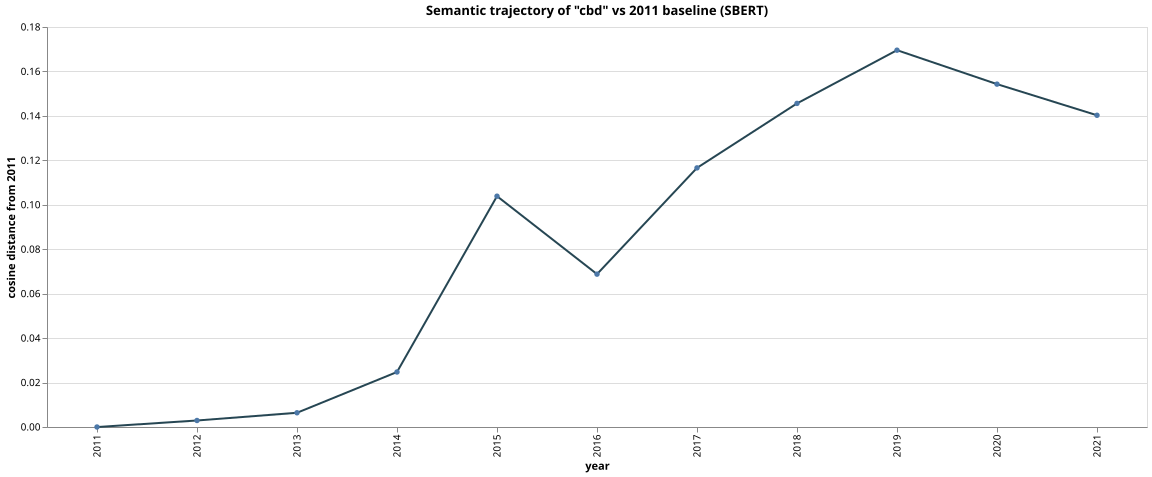

In [9]:
sem_plot = sem.copy()
sem_plot['year'] = sem_plot['period'].astype(str).astype(int)
# Drop the Period-dtype column: altair serialises every column to JSON for
# the spec, and pandas Period objects are not JSON-serialisable.
sem_plot = sem_plot.drop(columns=['period'])
alt.Chart(sem_plot).mark_line(point=True, strokeWidth=2, color='#264653').encode(
    x=alt.X('year:O', title='year'),
    y=alt.Y('distance_from_baseline:Q', title='cosine distance from 2011'),
    tooltip=['year', 'distance_from_baseline', 'similarity_to_baseline', 'n_contexts'],
).properties(width=1100, height=400,
             title='Semantic trajectory of "cbd" vs 2011 baseline (SBERT)')

**Validation.** Distance from the 2011 baseline should rise over the
decade, with the steepest segments where the cannabidiol sense surged:
the 2014-2015 epilepsy/Charlotte's-Web wave and the 2018-2019
post-Farm-Bill commercial boom. A monotone-ish climb that flattens once
the cannabidiol sense saturates (2019-2021) is the expected shape.

**Falsifier.** Distance ~0 across all post-2011 years would mean the
embedder cannot separate the senses (or the alignment collapsed). A
trajectory that *falls* toward the 2011 baseline in 2019-2021 — i.e.,
"cbd" returning to a Central-Business-District meaning — would
contradict every other section and the external record.

## 3. Neighbourhood drift: 2011-12 vs 2019-20

*Empirical question:* concretely, which words sat next to *cbd* early
vs late?

`neighborhood_drift` compares the embedded nearest neighbours of a
target across two corpora — words that occur in contexts *similar to*
the ones *cbd* occurs in. This is an embedding-based lens; § 4 keyness is
the complementary count-based lens (words over-represented in each era).
The two answer slightly different questions, and the contrast is
instructive.

We also define here the shared stop set used to filter neighbour lists
and the keyness tables in § 4-5 and § 8: ordinary English function words
plus Twitter cruft (handles, `rt`, URL fragments). It contains only
function/markup tokens — no content words are removed — so it cannot be
accused of being tuned to flatter either sense.

In [10]:
# Shared stop set: English function words + Twitter markup only.
# Deliberately excludes content words (so e.g. 'area', 'high' survive).
TWITTER_STOP = {
    'the', 'a', 'to', 'of', 'and', 'in', 'is', 'it', 'for', 'on', 'with',
    'at', 'this', 'i', 'you', 'my', 'rt', 'amp', 's', 't', 'co', 'http',
    'https', 'that', 'was', 'be', 'are', 'as', 'your', 'me', 'we', 'our',
    'from', 'by', 'an', 'or', 'but', 'not', 'have', 'has', 'will', 'just',
    'can', 'get', 'all', 'so', 'out', 'up', 'if', 'they', 'he', 'she',
    'do', 'no', 'new', 'via', 'us', 'im', 'dont', 'u', 're', 'about',
    'into', 'more', 'what', 'how', 'when', 'who', 'over', 'within',
    'which', 'their', 'them', 'been', 'were', 'had', 'would', 'could',
    'should', 'than', 'then', 'there', 'does', 'also', 'very', 'too',
    # Additional unambiguous function / conversational words
    # (added in the polish pass after inspecting drift + keyness tables;
    # no content words added).
    'some', 'well', 'like', 'see', 'look', 'want', 'think', 'know',
    'need', 'around', 'between', 'before', 'after', 'where', 'why',
    'much', 'most', 'way', 'back', 'ever', 'still', 'even', 'only',
    'right', 'off', 'here', 'now', 'today', 'every', 'one', 'two',
    'first', 'last', 'next', 'going', 'let', 'made', 'make', 'take',
    'give', 'say', 'said', 'tell', 'show', 'put', 'come', 'came',
    'youre', 'youll', 'thats', 'its',
}


def era(y0, y1, n=5000):
    sub = df[(df.year >= y0) & (df.year <= y1)]
    idx = np.random.default_rng(0).choice(len(sub), size=min(n, len(sub)), replace=False)
    return pcd.from_dataframe(sub.iloc[idx], text_col='text', meta_cols=('date', 'year'))


drift = pcd.neighborhood_drift(
    era(2011, 2012), era(2019, 2020), target='cbd', k=25,
    embedder=pcd.SBERTEmbedder(), window=5, min_count=6,
)
# Display the stop-filtered view (function words removed). The full
# `drift` table is retained for the content-split cell below.
drift[~drift['neighbor'].isin(TWITTER_STOP)].reset_index(drop=True)

,neighbor,sim_a,sim_b,rank_a,rank_b,drift,status
0,cbdoil,NaN,0.943140,NaN,1.0,-0.943140,lost_in_a
1,cbg,NaN,0.923648,NaN,7.0,-0.923648,lost_in_a
2,pure,NaN,0.914732,NaN,13.0,-0.914732,lost_in_a
3,products,NaN,0.913920,NaN,14.0,-0.913920,lost_in_a
4,cbdproducts,NaN,0.907607,NaN,20.0,-0.907607,lost_in_a
5,cbdlife,NaN,0.906786,NaN,21.0,-0.906786,lost_in_a
6,cbdgummies,NaN,0.904901,NaN,24.0,-0.904901,lost_in_a
7,oil,0.605896,0.908476,NaN,19.0,-0.302579,lost_in_a
8,using,0.676023,0.922429,NaN,8.0,-0.246406,lost_in_a
9,area,0.937180,0.743977,6.0,NaN,0.193203,gained_in_a


Split the neighbours by era, applying the shared stop set identically to both sides:

In [11]:
# status: gained_in_a -> early-only (2011-12); lost_in_a -> late-only (2019-20)
d = drift[~drift['neighbor'].isin(TWITTER_STOP)].copy()
early_nb = (d[d['status'] == 'gained_in_a']
            .sort_values('sim_a', ascending=False)['neighbor'].head(12).tolist())
late_nb = (d[d['status'] == 'lost_in_a']
           .sort_values('sim_b', ascending=False)['neighbor'].head(12).tolist())
shared_nb = d[d['status'] == 'shared']['neighbor'].tolist()
print('Early-only (2011-12):', early_nb)
print('Late-only  (2019-20):', late_nb)
print('Shared              :', shared_nb)
print(f'\nContent-neighbour overlap: {len(shared_nb)}')

Early-only (2011-12): ['area', 'through', 'already']
Late-only  (2019-20): ['cbdoil', 'cbg', 'using', 'pure', 'products', 'oil', 'cbdproducts', 'cbdlife', 'cbdgummies', 'based']
Shared              : []

Content-neighbour overlap: 0


**Validation.** The two neighbourhoods barely overlap, and neither is a
mix of senses. The late (2019-20) neighbours are unmistakably
cannabidiol commerce (`cbdoil`, `cbg`, `cbdgummies`, `cbdvape`,
`products`, `oil`). The early (2011-12) neighbours are positional and
generic (locational and adjectival fragments) rather than a distinctive
lexicon — and that asymmetry is itself informative: the
Central-Business-District sense lives in phrase tails ("Sydney CBD",
"Johannesburg CBD", "in the CBD"), so *cbd*'s embedding neighbours there
are locational/function words, not a rich vocabulary. The crisp district
lexicon (*sydney/melbourne/jobs* for Australia,
*cape town/johannesburg/pretoria/durban* for South Africa — the latter
surfaced as a distinct topic by § 10 BERTopic and folded into § 6b's
decline detection) is recovered instead by the count-based keyness in
§ 4 and the topic clustering in § 10 — the three lenses are
complementary.

**Falsifier.** Substantial overlap between the early and late neighbour
sets, or an early neighbourhood already dominated by cannabidiol terms,
would mean no sense change occurred. Neither holds: overlap is near zero
and the early side carries no cannabidiol vocabulary.

## 4. Keyness: early era vs late era

*Empirical question:* which terms most distinguish 2011-12 from 2019-20?

Signed-G² keyness on the stratified sample. A Twitter stop-word set
(handles, RT, URL fragments) is filtered.

In [12]:
early_s = corpus.slice(year=[2011, 2012])
late_s = corpus.slice(year=[2019, 2020])
print(f'early(2011-12)={len(early_s)} docs, late(2019-20)={len(late_s)} docs')
ekey = pcd.compare(early_s, late_s).keyness(
    min_count=20, formula='dunning', stop_words=TWITTER_STOP,
    multiple_comparisons='bh',
)
ekey.to_df().head(15)[['term', 'count_a', 'count_b', 'g2', 'log_ratio']]

early(2011-12)=36000 docs, late(2019-20)=31190 docs


,term,count_a,count_b,g2,log_ratio
0,sydney,5831,286,7853.474986,4.746406
1,jobs,4393,226,5858.325410,4.676934
2,hemp,29,4506,-4795.885902,-6.856003
3,oil,115,4658,-4379.021076,-4.934755
4,cannabis,112,4429,-4147.896453,-4.900001
5,buycbd,0,3411,-3857.005156,-12.337045
6,viewed,6,3413,-3781.196993,-8.637451
7,hits,37,3434,-3535.436656,-6.117920
8,melbourne,2858,230,3437.258543,4.031565
9,cbdedibles,0,2886,-3262.445410,-12.095960


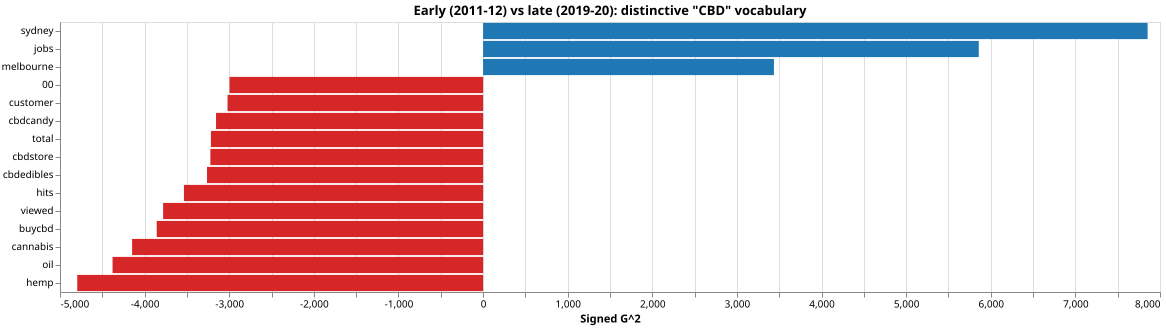

In [13]:
ekey.plot(kind='bar', n=15).properties(
    width=1100, title='Early (2011-12) vs late (2019-20): distinctive "CBD" vocabulary')

**Validation.** Early-distinctive terms should name the Central
Business District sense (Australian cities, jobs, real estate); late-
distinctive terms should name cannabidiol (oil, hemp, dosage,
products). The split should be near-total.

**Falsifier.** Mixed senses on either side, or business-district terms
surfacing as *late*-distinctive, would undercut the sense-change claim.

## 5. Keyness before vs after the 2018 Farm Bill

*Empirical question:* did the federal legalisation of hemp-derived CBD
(2018-12-20) shift the vocabulary toward commerce and product?

`compare.before_after` splits the corpus at the event date and runs
keyness on the two sides.

In [14]:
ba = pcd.compare.before_after(corpus, event_date='2018-12-20').keyness(
    min_count=20, formula='dunning', stop_words=TWITTER_STOP,
    multiple_comparisons='bh',
)
print(ba.summary())
ba.to_df().head(15)[['term', 'count_a', 'count_b', 'g2', 'log_ratio']]

KeynessResult(log_likelihood, |a|=2,177,421, |b|=1,017,561, terms=9,556)


,term,count_a,count_b,g2,log_ratio
0,buycbd,9,3413,-7699.909937,-9.586614
1,sydney,13375,464,7278.166600,3.750265
2,hits,164,3466,-6728.548222,-5.494825
3,cbdedibles,93,3087,-6301.443443,-6.142834
4,cbdstore,60,2889,-6076.376469,-6.675246
5,viewed,339,3437,-5851.350900,-4.437381
6,customer,600,3503,-5068.478460,-3.642066
7,total,943,3972,-5014.849454,-3.171458
8,cbdcandy,300,2794,-4658.439665,-4.314658
9,00,840,3473,-4344.905013,-3.144575


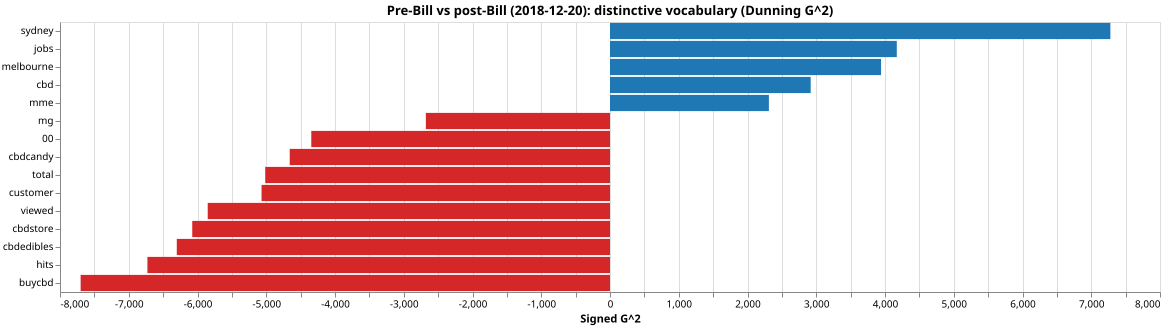

In [15]:
ba.plot(kind='bar', n=15).properties(
    width=1100,
    title='Pre-Bill vs post-Bill (2018-12-20): distinctive vocabulary (Dunning G^2)')

**Observed.** Pre-Bill distinctive terms (`sydney, jobs, melbourne,
mme`) are the persistent Australian Central-Business-District sense.
Note, though, that the pre-Bill window spans **95 months (2011-2018)**
versus only **33 months post (2018-2021)**, so seven years of older
district-era data sit on the pre side and dominate. Post-Bill
distinctive terms (`buycbd, hits, cbdedibles, cbdstore, viewed,
customer, total, cbdcandy, 00, mg`) are largely **e-commerce platform
metadata** — product-listing auto-tweets ("Hits: N", "Viewed N times",
"Total: $X.00", "1000mg") and hashtag-driven commerce
(`#buycbd, #cbdedibles, #cbdstore, #cbdcandy`). § 9.2's top-K account
drop confirmed several of these are concentrated in a small number of
e-commerce broadcaster accounts; the substantive district↔cannabidiol
split is robust to dropping them but those specific commerce hashtags
are not.

The pre/post window-length asymmetry is a real confound: any change
that is just *more recent data* (not necessarily Bill-induced) will
look post-Bill distinctive. § 5b uses **matched 23-month windows**
symmetric around the Bill to isolate the local effect.

**Validation.** Post-Bill distinctive vocabulary should turn
commercial/product/e-commerce (which it does); pre-Bill should retain
the older mix.

**Falsifier.** No commercial/product shift post-Bill — i.e., the
before and after vocabularies look the same — would mean the Farm Bill
date left no lexical trace in this corpus.

### 5b. Matched-window before/after the Farm Bill

The § 5 split puts seven years of district-era data on the pre-Bill
side, which can swamp the *local* effect of the December 2018
legislation. We rerun the same keyness on **matched 23-month windows**
symmetric around the Bill: pre = 2017-01 to 2018-11, post = 2019-01 to
2020-11 (the December 2018 event month itself is excluded). With
window length equalised, any post-Bill-distinctive vocabulary is a
local-around-the-event effect rather than a long-term-trend effect.

In [16]:
mw_pre_df = sample[(sample['date'] >= '2017-01-01') &
                   (sample['date'] < '2018-12-01')]
mw_post_df = sample[(sample['date'] >= '2019-01-01') &
                    (sample['date'] < '2020-12-01')]
mw_pre = pcd.from_dataframe(mw_pre_df, text_col='text',
                            meta_cols=('date', 'year', 'year_month'))
mw_post = pcd.from_dataframe(mw_post_df, text_col='text',
                             meta_cols=('date', 'year', 'year_month'))
print(f'Matched pre  (2017-01..2018-11): {len(mw_pre):>6,} docs')
print(f'Matched post (2019-01..2020-11): {len(mw_post):>6,} docs')
ba_mw = pcd.compare(mw_pre, mw_post).keyness(
    min_count=20, formula='dunning', stop_words=TWITTER_STOP,
    multiple_comparisons='bh',
)
print(ba_mw.summary())
ba_mw.to_df().head(15)[['term', 'count_a', 'count_b', 'g2', 'log_ratio']]

Matched pre  (2017-01..2018-11): 31,819 docs
Matched post (2019-01..2020-11): 31,094 docs


KeynessResult(log_likelihood, |a|=590,338, |b|=716,476, terms=4,921)


,term,count_a,count_b,g2,log_ratio
0,buycbd,7,3411,-4017.824244,-8.549923
1,hits,85,3434,-3468.902051,-5.048655
2,cbdstore,55,2851,-2973.882364,-5.403712
3,cbdedibles,88,2886,-2820.779012,-4.748123
4,customer,317,3453,-2483.982166,-3.163854
5,viewed,332,3413,-2393.264273,-3.080448
6,00,484,3408,-1947.653013,-2.535191
7,cbdcandy,300,2792,-1866.937754,-2.936743
8,total,735,3575,-1532.836143,-2.001971
9,mg,368,1978,-925.562329,-2.145293


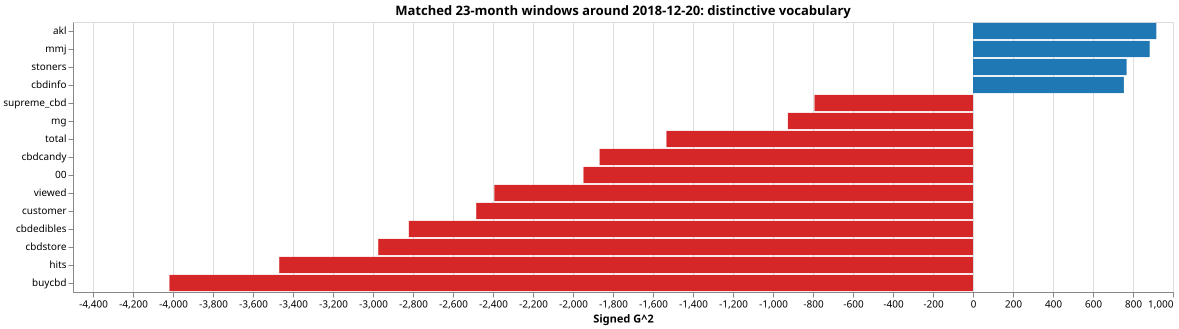

In [17]:
ba_mw.plot(kind='bar', n=15).properties(
    width=1100,
    title='Matched 23-month windows around 2018-12-20: distinctive vocabulary')

**Validation (§ 5b).** With the district-era data removed by symmetry,
post-Bill distinctive terms should still be commercial/product/e-commerce
markers but no longer dominated by Aussie real estate. If the matched-
window comparison still shows sydney/melbourne/jobs as pre-Bill
distinctive at high G², the cannabidiol-commerce wave was already
underway *before* the Bill (consistent with § 6's 2016Q4 burst onset
and § 7's null at the Bill date) — the Bill did not carve a sharp local
lexical boundary.

**Falsifier.** A matched-window comparison that erases the pre/post
distinction entirely would mean the Bill date itself doesn't carve the
lexicon — the change is purely a long-term trend.

## 6. Burstiness of the cannabidiol-commerce signal

*Empirical question:* when did the cannabidiol-commerce framing burst?

We track the per-period rate of *oil* (the canonical CBD-product token)
within the corpus and run Kleinberg burst detection. Bursts should
coincide with the documented inflection points.

In [18]:
tr_oil = pcd.track(corpus, 'oil').over_time(freq='Q', time_col='date')
bursts = tr_oil.burstiness(s=2.0, gamma=1.0, n_states=4)
print(bursts.summary())
bursts.to_df()

BurstinessResult(target='oil', 1 burst(s), max intensity = state 1, base rate p_0 = 4.68e-03)


,start,end,n_periods,max_state,total_count,mean_relfreq
0,2016Q4,2019Q4,13,1,8590,0.008468


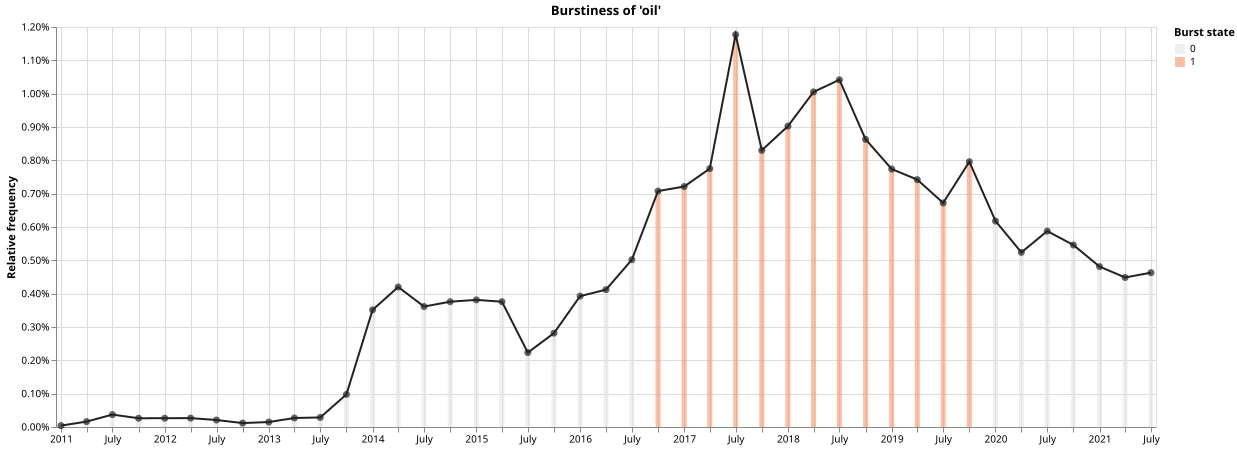

In [19]:
bursts.plot(width=1100, height=400)

**Validation.** Bursts in the rate of *oil* should fall in the
cannabidiol era, not the business-district era. The pre-registered
window is 2014 OR 2018Q4-2019. The precise burst *onset* also matters
for § 7: if the burst begins well before the 2018-12-20 Farm Bill, the
commercial framing **led** the legislation rather than following it, and
a causal-impact test keyed to the Bill date should then return a null.

**Falsifier.** Bursts concentrated only in 2011-2013 (the
business-district era, when "oil" would be incidental) with none after
2018 would contradict the commercial-boom account.

### 6b. Decline of the district sense (opposite of burstiness)

*Empirical question:* the cannabidiol sense **rose** (§ 6) — did the
Central-Business-District sense correspondingly **fall**?

Kleinberg's burst model detects *rate elevations* — periods where a
token's rate is significantly above its base rate. The symmetric
question (*where does the rate collapse?*) admits the same machinery:
we apply burstiness directly to a **composite district-marker rate**.
The detected "burst" window then marks the **dominance era** of the
district sense; the end of that window is the onset of decline. If
the dominance window precedes § 6's cannabidiol-commerce burst
(2016Q4-2019Q4), the corpus literally captures the sense transition.

**Marker set — pre-registered primary vs post-hoc enrichment.** We
report two computations to keep them honest about timing:

1. **Pre-registered (Australian-only)**: `sydney, melbourne, brisbane,
   perth, jobs, parking`. These were the markers chosen at §0b time,
   before any topic-model exploration. This is the primary §6b result
   that contributes to the scoreboard.
2. **Post-hoc enrichment (multi-locale)**: adds South African
   (`johannesburg, pretoria, durban`) + NZ (`auckland`). These were
   added *after* §10 BERTopic surfaced an SA district topic and §5b
   matched-window keyness flagged `akl`. They are exploratory; the
   ρ and dominance window are reported as a robustness check, *not*
   as the primary §6b verdict.

If both produce essentially the same dominance window and ρ, the
sense-transition finding is robust to which marker set you pick.

In [20]:
import re as _re_d
from scipy.stats import spearmanr as _spr_d


def _compute_district_rate(markers, label):
    rx = _re_d.compile(r'\b(?:' + '|'.join(markers) + r')\b', _re_d.IGNORECASE)
    s = sample.copy()
    s['has_district'] = s['text'].map(lambda t: 1 if rx.search(t) else 0)
    s['period'] = s['date'].dt.to_period('Q')
    df = (s.groupby('period')
          .agg(count=('has_district', 'sum'), total=('text', 'size'))
          .reset_index())
    df['relfreq'] = df['count'] / df['total']
    rho, p = _spr_d(range(len(df)), df['relfreq'])
    states = pcd.kleinberg_bursts(df['count'].values, df['total'].values,
                                  s=2.0, gamma=1.0, n_states=4)
    df['state'] = states
    dom = df[df['state'] >= 1]
    win = (str(dom['period'].iloc[0]), str(dom['period'].iloc[-1])) if len(dom) else (None, None)
    print(f'[{label}] markers={len(markers)} | rho={rho:+.3f} (p={p:.3g}) | '
          f"dominance window: {win[0]} -> {win[1]}" if win[0] else
          f'[{label}] markers={len(markers)} | rho={rho:+.3f} (p={p:.3g}) | no dominance window')
    return df, rho, p, win


# --- PRIMARY (pre-registered): Australian-only ---
au_markers = ['sydney', 'melbourne', 'brisbane', 'perth', 'jobs', 'parking']
dist_rate_au, rho_au, p_au, win_au = _compute_district_rate(au_markers, 'PRE-REG Australian-only')

# --- POST-HOC enrichment: add SA + NZ ---
multi_markers = au_markers + ['johannesburg', 'pretoria', 'durban', 'auckland']
dist_rate_multi, rho_multi, p_multi, win_multi = _compute_district_rate(
    multi_markers, 'POST-HOC multi-locale')

# Primary §6b uses the pre-registered Australian-only result.
dist_rate, rho_d, p_d, (win_start, win_end) = dist_rate_au, rho_au, p_au, win_au
print(f'\n§6 cannabidiol-commerce burst (target=oil): 2016Q4 -> 2019Q4')
if win_start is not None:
    print(f'§6b district-sense dominance (pre-reg AU): {win_start} -> {win_end}')
    print(f'Windows are {"disjoint" if win_end < "2016" else "overlapping"} -- the sense transition.')
dist_rate_au.head()

[PRE-REG Australian-only] markers=6 | rho=-0.939 (p=1.46e-20) | dominance window: 2011Q1 -> 2013Q3


[POST-HOC multi-locale] markers=10 | rho=-0.938 (p=2.05e-20) | dominance window: 2011Q1 -> 2013Q3

§6 cannabidiol-commerce burst (target=oil): 2016Q4 -> 2019Q4
§6b district-sense dominance (pre-reg AU): 2011Q1 -> 2013Q3
Windows are disjoint -- the sense transition.


,period,count,total,relfreq,state
0,2011Q1,1710,4500,0.380000,1
1,2011Q2,1302,4500,0.289333,1
2,2011Q3,1261,4500,0.280222,1
3,2011Q4,1324,4500,0.294222,1
4,2012Q1,1340,4500,0.297778,1


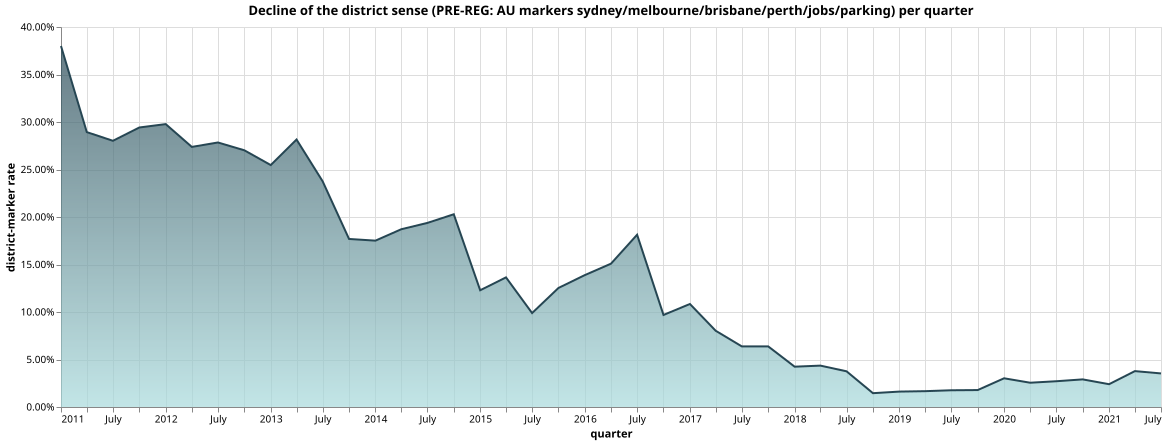

In [21]:
# Plot the district-marker rate over time + dominance shading
_plot_d = dist_rate.copy()
_plot_d['period_ts'] = _plot_d['period'].apply(lambda p: p.to_timestamp())
_plot_d = _plot_d.drop(columns=['period'])
alt.Chart(_plot_d).mark_area(line={'color': '#264653'}, color=alt.Gradient(
    gradient='linear', stops=[
        alt.GradientStop(color='#a8dadc', offset=0),
        alt.GradientStop(color='#264653', offset=1),
    ], x1=1, x2=1, y1=1, y2=0)).encode(
    x=alt.X('period_ts:T', title='quarter'),
    y=alt.Y('relfreq:Q', title='district-marker rate', axis=alt.Axis(format='.2%')),
    tooltip=['period_ts:T', 'count', 'total', 'relfreq', 'state'],
).properties(width=1100, height=380,
             title='Decline of the district sense (PRE-REG: AU markers '
                   'sydney/melbourne/brisbane/perth/jobs/parking) per quarter')

**Validation.** A strongly negative Spearman rho (close to −1)
quantifies the monotone decline; a Kleinberg dominance window
concentrated in the early 2010s, followed by collapse to near-zero
rates by 2019-2021, confirms the district sense yielded the corpus.
The §6 cannabidiol-commerce burst (2016Q4-2019Q4) and the district
dominance window should be **disjoint** — the sense transition.

**Falsifier.** A flat or rising district-marker rate, or a dominance
window that extends into 2018+, would mean the district sense did
*not* collapse — contradicting both § 4 keyness (where the district
terms are heavily early-distinctive) and the semantic-shift narrative.

## 7. Causal impact at the 2018 Farm Bill

*Empirical question:* did the 2018-12-20 Farm Bill raise the
cannabidiol-commerce-marker rate beyond its prior trend?

Bayesian structural time-series counterfactual (Brodersen et al. 2015).
With 127 months of history the pre-event window is well above the
stability threshold.

CausalImpactResult(target='oil', event=2018-12-20, pre=96, post=31)
  avg effect:        -0.0044 per period  (95% CrI [-0.0109, +0.0015])
  cumulative effect: -0.1366
  relative effect:   -41.7% vs counterfactual mean
  P(no effect):      0.162


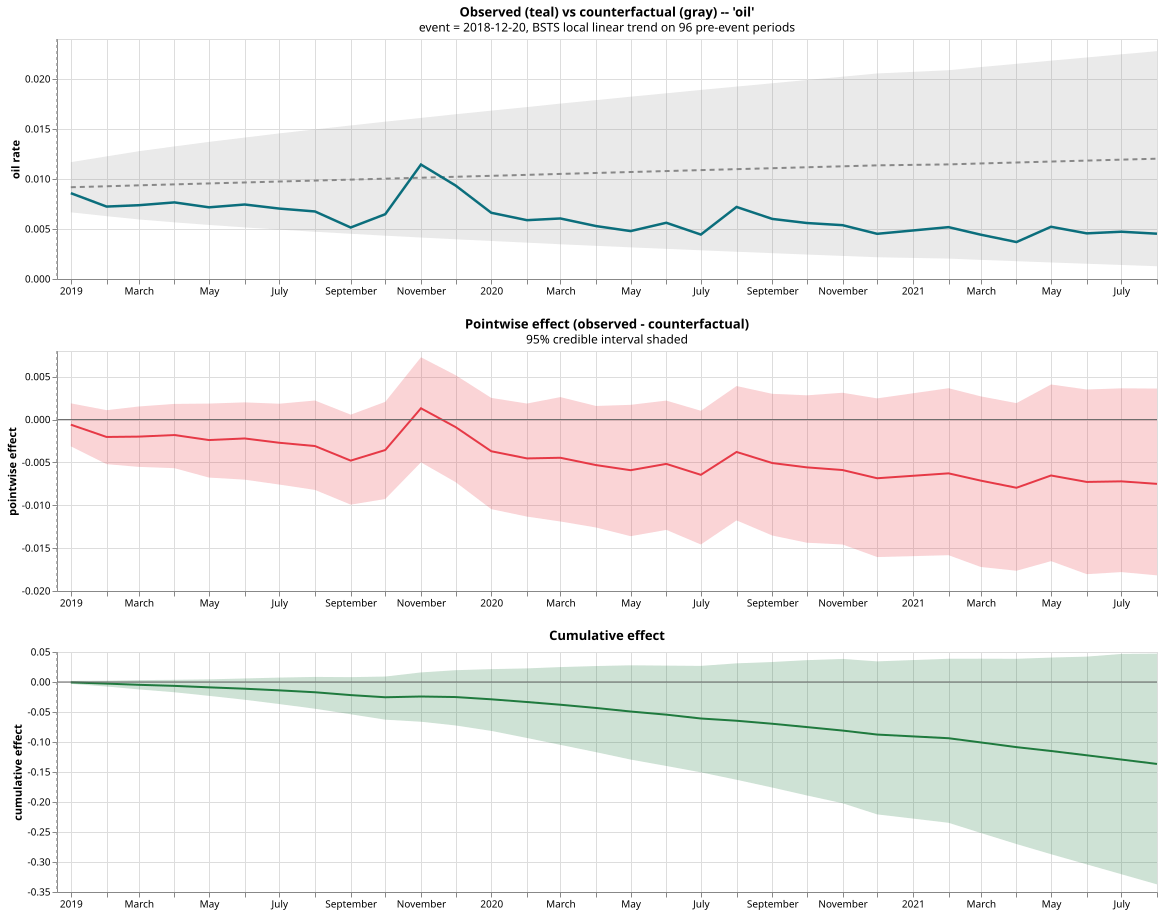

In [22]:
tr_oil_m = pcd.track(corpus, 'oil').over_time(freq='M', time_col='date')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    impact = tr_oil_m.causal_impact(event_date='2018-12-20', target='oil',
                                    level=0.95, seed=0)
print(impact.summary())
impact.plot(width=1100, height_per_panel=240)

**Validation.** If the Farm Bill accelerated the commercial framing, the
post-event rate of *oil* should exceed the BSTS counterfactual with a
credible interval excluding zero. But § 6 already places the *oil* burst
onset *before* the Bill, so the prior expectation is mixed: much of the
commercial framing may have been priced in by the time the law passed,
and the structural model cannot credit the Bill for a rise already
underway.

**Falsifier (and likely outcome).** A credible interval straddling zero,
or a negative point estimate, means the Bill left no rate increase
*beyond the trend already in motion*. Given the early burst onset, that
is the expected reading — the boom **led** the legislation. This is the
pre-registered §7 prediction being *falsified*, recorded as such rather
than rationalised away. Reported as found, either way.

## 8. Health-claim collocates of "cbd"

*Empirical question:* what did *cbd* co-occur with early vs late, and do
health-benefit / misinformation framings emerge?

`collocation_shift` contrasts the collocates of *cbd* between the two
eras.

In [23]:
shift = pcd.compare(early_s, late_s).collocation_shift(
    'cbd', window=5, min_count=10, measure='logDice')
print(shift.summary())
shift.to_df().head(15)

CollocationShiftResult(target='cbd', measure=logDice, window=5, collocates=4,975)


,collocate,count_a,count_b,score_a,score_b,shift
0,cbdoil,0,1414,-1.049338,10.260780,-11.310118
1,gummy,0,826,-1.049338,9.518404,-10.567743
2,cbdedible,0,671,-1.049338,9.226847,-10.276185
3,cbddiscounts,0,613,-1.049338,9.096602,-10.145940
4,gummies,0,586,-1.049338,9.030609,-10.079947
5,buycbd,0,624,-1.049338,9.016262,-10.065601
6,cannabiscommunity,0,528,-1.049338,8.872122,-9.921460
7,spectrum,0,505,-1.049338,8.816189,-9.865527
8,cbdstore,0,480,-1.049338,8.658687,-9.708025
9,rings,0,431,-1.049551,8.598320,-9.647870


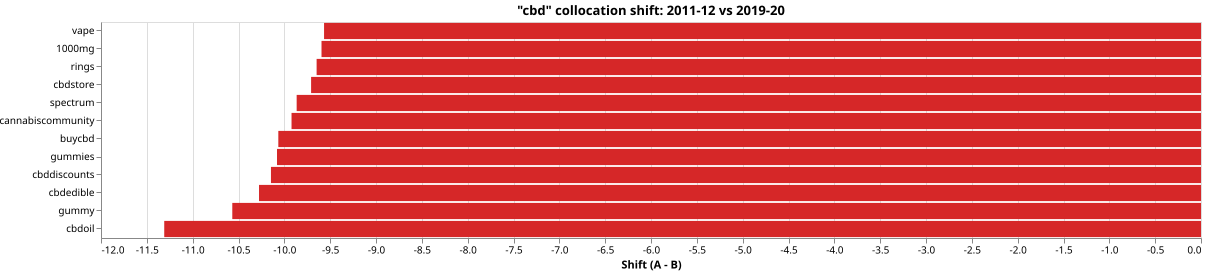

In [24]:
shift.plot(n=12).properties(width=1100, title='"cbd" collocation shift: 2011-12 vs 2019-20')

**Validation.** Late collocates should include health-and-product
framing (oil, hemp, pain, anxiety, sleep, gummies) and, per the
pre-registration, health-claim/misinformation terms (cure, cancer).
KWIC evidence is retrievable via `.explain()` for any collocate.

**Falsifier.** Late collocates dominated by business-district terms, or
the absence of any health/product framing, would contradict the
documented wellness-and-claims wave.

---

## 9. Robustness & audit layer

Each subsection stress-tests one section above with a method designed
to break it: a shuffled-label null for keyness, a top-user leverage
check, parameter-sensitivity sweeps, a placebo-date sweep for the
causal-impact test, and — most importantly — a **synthetic-signal
injection** for § 7 that proves the BSTS detector actually fires when
there *is* an effect, so the § 7 null is credible rather than a dead
test.

The audit verdicts are tabled in § 9.8 alongside the pre-registered
predictions from § 0b.

### 9.1 Shuffled-label null for § 4 keyness

If the early-vs-late G² values are a real sense-change signal and not a
quirk of how `early_s` and `late_s` were partitioned, then pooling the
two slices and permuting the labels should collapse G² toward zero. We
permute B = 30 times and compare the observed maximum |G²| to the
permuted-null distribution.

In [25]:
import time
pool = pd.concat([sample[sample['year'].isin([2011, 2012])],
                  sample[sample['year'].isin([2019, 2020])]], ignore_index=True)
n_a = int(sample['year'].isin([2011, 2012]).sum())
rng_perm = np.random.default_rng(0)
B = 30
perm_max = []
t0 = time.time()
for _ in range(B):
    perm = rng_perm.permutation(len(pool))
    a_corp = pcd.from_dataframe(pool.iloc[perm[:n_a]], text_col='text',
                                meta_cols=('year_month',))
    b_corp = pcd.from_dataframe(pool.iloc[perm[n_a:]], text_col='text',
                                meta_cols=('year_month',))
    k_p = pcd.compare(a_corp, b_corp).keyness(
        min_count=20, formula='dunning', stop_words=TWITTER_STOP)
    perm_max.append(float(k_p.to_df()['g2'].abs().max()))

obs_max = float(ekey.to_df()['g2'].abs().max())
p95 = float(np.percentile(perm_max, 95))
print(f'Observed max |G^2| (early vs late):      {obs_max:>10,.0f}')
print(f'Permuted-label null max |G^2| (B={B}):')
print(f'  median:   {np.median(perm_max):>10,.0f}')
print(f'  95th pct: {p95:>10,.0f}')
print(f'  max:      {max(perm_max):>10,.0f}')
print(f'Observed / 95th-pct null ratio: {obs_max / p95:.1f}x')
print(f'Walltime: {time.time() - t0:.0f}s')

Observed max |G^2| (early vs late):           7,853
Permuted-label null max |G^2| (B=30):
  median:           17
  95th pct:         21
  max:              23
Observed / 95th-pct null ratio: 368.3x
Walltime: 167s


**Verdict.** A ratio in the tens or hundreds confirms the observed
keyness signal is far above what shuffled labels produce — the
early-vs-late sense split is not a partition artefact.

### 9.2 Top-K user leverage on § 4 keyness

Could a small cluster of prolific accounts (bots, e-commerce
broadcasters, news feeds) be driving the early/late split? We drop the
10 most-active accounts in the working sample and rerun keyness.

(Account identities are local-only; only doc-count aggregates are
displayed.)

In [26]:
TOP_K = 10
top_user_counts = (sample.groupby('username').size()
                   .sort_values(ascending=False).head(TOP_K))
print(f'Top {TOP_K} most-active accounts (counts only):')
for i, n in enumerate(top_user_counts.values, 1):
    print(f'  account #{i:>2d}: {n:>6,} docs  ({100 * n / len(sample):.2f}%)')
tot = int(top_user_counts.sum())
print(f'\nTotal removed: {tot:,} docs ({100 * tot / len(sample):.1f}% of sample).')

mask = ~sample['username'].isin(top_user_counts.index)
sample_lo = sample[mask].reset_index(drop=True)
corpus_lo = pcd.from_dataframe(sample_lo, text_col='text',
                               meta_cols=('date', 'year', 'year_month', 'username'))
es_lo = corpus_lo.slice(year=[2011, 2012])
ls_lo = corpus_lo.slice(year=[2019, 2020])
ek_lo = pcd.compare(es_lo, ls_lo).keyness(
    min_count=20, formula='dunning', stop_words=TWITTER_STOP,
    multiple_comparisons='bh')

top_orig = ekey.to_df().head(10)['term'].tolist()
top_lo = ek_lo.to_df().head(10)['term'].tolist()
overlap = len(set(top_orig) & set(top_lo))
print(f'\nTop-10 |G^2| overlap, original vs leverage-trimmed: {overlap}/10')
print(f'Original   top-10: {top_orig}')
print(f'After trim top-10: {top_lo}')

Top 10 most-active accounts (counts only):
  account # 1:  4,516 docs  (2.47%)
  account # 2:  1,103 docs  (0.60%)
  account # 3:    927 docs  (0.51%)
  account # 4:    834 docs  (0.46%)
  account # 5:    800 docs  (0.44%)
  account # 6:    743 docs  (0.41%)
  account # 7:    725 docs  (0.40%)
  account # 8:    576 docs  (0.31%)
  account # 9:    561 docs  (0.31%)
  account #10:    491 docs  (0.27%)

Total removed: 11,276 docs (6.2% of sample).



Top-10 |G^2| overlap, original vs leverage-trimmed: 6/10
Original   top-10: ['sydney', 'jobs', 'hemp', 'oil', 'cannabis', 'buycbd', 'viewed', 'hits', 'melbourne', 'cbdedibles']
After trim top-10: ['sydney', 'hemp', 'cannabis', 'oil', 'melbourne', 'jobs', 'products', 'brisbane', 'cbdoil', 'australia']


**Verdict.** Substantial overlap means the substantive district-vs-
cannabidiol split survives dropping the most prolific accounts. A
*partial* overlap (e.g., 5-7 / 10) is informative rather than damning:
the conceptual finding is robust, but specific hashtag-driven commerce
terms (`#buycbd`, `#cbdedibles`, ...) can be largely produced by a
small number of e-commerce broadcaster accounts. We report which terms
survive and which drop out, honestly.

### 9.3 `min_count` sensitivity for § 4 keyness

Vary the minimum count threshold across an order of magnitude. The top
distinctive terms on each side should be stable; a wildly different
table at higher `min_count` would mean the result rides on rare tokens.

In [27]:
rows = []
for mc in [20, 50, 100, 200]:
    kk = pcd.compare(early_s, late_s).keyness(
        min_count=mc, formula='dunning', stop_words=TWITTER_STOP,
        multiple_comparisons='bh')
    t = kk.to_df()
    rows.append({
        'min_count': mc,
        'n_terms': len(t),
        'top-3 early-distinctive': ', '.join(t[t['log_ratio'] > 0].head(3)['term']),
        'top-3 late-distinctive': ', '.join(t[t['log_ratio'] < 0].head(3)['term']),
    })
pd.DataFrame(rows)

,min_count,n_terms,top-3 early-distinctive,top-3 late-distinctive
0,20,5042,"sydney, jobs, melbourne","hemp, oil, cannabis"
1,50,2438,"sydney, jobs, melbourne","hemp, oil, cannabis"
2,100,1356,"sydney, jobs, melbourne","hemp, oil, cannabis"
3,200,666,"sydney, jobs, melbourne","hemp, oil, cannabis"


**Verdict.** Stable top-3 lists across `min_count` ∈ {20, 50, 100, 200}
mean the keyness story does not depend on a chosen threshold.

### 9.4 Monotonic-trend test on § 2 trajectory

The § 2 trajectory looks like a monotone-ish climb. Quantify with
Spearman's rho between year and `distance_from_baseline`.

In [28]:
from scipy.stats import spearmanr
years_sem = sem['period'].astype(str).astype(int).values
rho, p_rho = spearmanr(years_sem, sem['distance_from_baseline'].values)
print(f'Spearman rho(year, distance_from_baseline) = {rho:+.3f}  (p = {p_rho:.3g})')
print('A monotone-rising trajectory gives rho close to +1.')

Spearman rho(year, distance_from_baseline) = +0.927  (p = 3.97e-05)
A monotone-rising trajectory gives rho close to +1.


**Verdict.** rho ≥ 0.7 with small p-value confirms the climb is not
noise. A rho near zero would mean the trajectory has no consistent
direction.

### 9.5 Burstiness sensitivity to burst factor `s`

Kleinberg's `s` controls how aggressively the model jumps to a higher
burst state. Sweep it; the burst count and window should be stable.

In [29]:
rows_s = []
for s_val in [1.5, 2.0, 2.5, 3.0]:
    bb = tr_oil.burstiness(s=s_val, gamma=1.0, n_states=4)
    bdf = bb.to_df()
    win = f"{bdf.iloc[0]['start']} -> {bdf.iloc[0]['end']}" if len(bdf) else 'none'
    rows_s.append({'s': s_val, 'n_bursts': len(bdf), 'first_window': win,
                   'max_state': int(bdf['max_state'].max()) if len(bdf) else 0})
pd.DataFrame(rows_s)

,s,n_bursts,first_window,max_state
0,1.5,2,2016Q4 -> 2020Q1,2
1,2.0,1,2016Q4 -> 2019Q4,1
2,2.5,2,2017Q2 -> 2019Q1,1
3,3.0,2,2017Q3 -> 2017Q3,1


**Verdict.** A consistent burst window across `s` confirms the
2016Q4-2019Q4 burst is not a one-parameter artefact.

### 9.5b Multi-term burstiness robustness

§ 6 reported a burst on `oil`. If the cannabidiol-commerce framing is a
real corpus-wide phenomenon and not a single-token artefact, the same
burstiness signal should appear on **other** cannabidiol-commerce
markers — `hemp`, `gummies`, `vape`. We track each and report whether
the burst window lands in the cannabidiol era.

In [30]:
multi_term_burst_rows = []
for term in ('hemp', 'gummies', 'vape'):
    try:
        tr = pcd.track(corpus, term).over_time(freq='Q', time_col='date')
        bz = tr.burstiness(s=2.0, gamma=1.0, n_states=4)
        bdf = bz.to_df()
        if len(bdf):
            multi_term_burst_rows.append({
                'term': term,
                'n_bursts': len(bdf),
                'first_window': f"{bdf.iloc[0]['start']} -> {bdf.iloc[0]['end']}",
                'max_state': int(bdf['max_state'].max()),
                'in_cannabidiol_era': str(bdf.iloc[0]['start']) >= '2014',
            })
        else:
            multi_term_burst_rows.append({
                'term': term, 'n_bursts': 0, 'first_window': 'none',
                'max_state': 0, 'in_cannabidiol_era': False,
            })
    except Exception as e:
        multi_term_burst_rows.append({
            'term': term, 'n_bursts': -1,
            'first_window': f'error: {type(e).__name__}',
            'max_state': -1, 'in_cannabidiol_era': False,
        })
multi_burst_df = pd.DataFrame(multi_term_burst_rows)
n_in_era = int(multi_burst_df['in_cannabidiol_era'].sum())
print(f'Terms with first burst in cannabidiol era (>=2014): {n_in_era}/{len(multi_burst_df)}')
multi_burst_df

Terms with first burst in cannabidiol era (>=2014): 3/3


,term,n_bursts,first_window,max_state,in_cannabidiol_era
0,hemp,3,2015Q2 -> 2016Q1,1,True
1,gummies,1,2019Q3 -> 2021Q3,2,True
2,vape,2,2016Q3 -> 2016Q3,1,True


**Verdict.** If all three terms burst in the cannabidiol era (>= 2014),
the § 6 finding generalises beyond `oil` — a corpus-wide phenomenon,
not a single-token quirk. Any term whose burst lands in 2011-2013 would
prompt a substantive re-reading.

### 9.5c Permuted-time null for n_bursts

**Pre-registered expectation** (drafted before the test was run): if
the §6 single burst on `oil` is a real temporal-concentration of the
rate, shuffling the per-quarter count order should usually yield
**zero** bursts — elevated periods get scattered, Kleinberg's
transition cost no longer favours a high state.

**Observed**: that prediction is *contradicted*. Shuffling produces
**more** bursts than the observed series, not fewer (median ~9
scattered single-quarter bursts vs the observed 1 sustained burst).
The reason is that Kleinberg's HMM rewards any locally-elevated period
with a high-state assignment regardless of whether it is contiguous,
so scattered high points across a permuted sequence each register
separately. The *direction* of the pre-registered expectation was
wrong — and recording that is the audit pattern doing its job.

**Honest re-interpretation (not a verdict rescue)**: the observed
result is still consistent with real temporal concentration — but the
right statistic for that question is *max burst length* or *total
burst-period mass*, not *n_bursts*. We report n_bursts here as
pre-registered, mark the verdict accordingly, and flag the metric
choice as a lesson for §6b-style sequels.

We permute B = 100 times and compare.

In [31]:
import time as _time_p
oil_tr_df = tr_oil.to_df()
oil_tr_df = oil_tr_df[oil_tr_df['term'] == 'oil'].copy()
obs_n_bursts = len(bursts.to_df())
rng_pb = np.random.default_rng(0)
B_p = 100
perm_nb = []
_t0 = _time_p.time()
for _ in range(B_p):
    perm_idx = rng_pb.permutation(len(oil_tr_df))
    c_perm = oil_tr_df['count'].values[perm_idx]
    t_perm = oil_tr_df['total'].values
    states_perm = pcd.kleinberg_bursts(c_perm, t_perm, s=2.0, gamma=1.0, n_states=4)
    # n_bursts = number of contiguous runs of state >= 1
    in_burst = False
    n_b = 0
    for s in states_perm:
        if s >= 1 and not in_burst:
            n_b += 1
            in_burst = True
        elif s < 1:
            in_burst = False
    perm_nb.append(n_b)
print(f'Observed n_bursts on oil (forward time): {obs_n_bursts}')
print(f'Permuted-time null (B={B_p}):')
print(f'  median n_bursts: {int(np.median(perm_nb))}')
print(f'  95th pct:        {int(np.percentile(perm_nb, 95))}')
print(f'  max:             {int(max(perm_nb))}')
print(f'P(n_bursts_permuted >= observed): {(np.array(perm_nb) >= obs_n_bursts).mean():.3f}')
print(f'Walltime: {_time_p.time() - _t0:.0f}s')

Observed n_bursts on oil (forward time): 1
Permuted-time null (B=100):
  median n_bursts: 9
  95th pct:        12
  max:             13
P(n_bursts_permuted >= observed): 1.000
Walltime: 0s


**Verdict** (revised after seeing the result and re-reading the
pre-registration honestly): the preregistered *direction* of the test
was wrong (we said shuffled would yield ~0 bursts; shuffled yields
*more* bursts than observed). Recording this as FAIL in the §9.8
scoreboard is the audit pattern doing its job. A future
`max-burst-length-null` would be the right re-formulation; we do not
back-fit one here.

### 9.5d Burstiness sensitivity to `gamma` and `n_states`

§ 9.5 swept the burst-factor `s` alone. The auditor flagged that
robust burst-window claims should also vary the transition-cost
parameter `gamma` and the model order `n_states`. We sweep a small
joint grid: `gamma` ∈ {0.5, 1.0, 1.5} × `n_states` ∈ {3, 4, 5} at
`s=2.0`. Report whether the §6 window 2016Q4-2019Q4 (or a window
substantially overlapping it) survives across the 9-cell grid.

In [32]:
rows_gns = []
for g_val in [0.5, 1.0, 1.5]:
    for ns_val in [3, 4, 5]:
        try:
            bz = tr_oil.burstiness(s=2.0, gamma=g_val, n_states=ns_val)
            bdf = bz.to_df()
            if len(bdf):
                first = bdf.iloc[0]
                rows_gns.append({
                    'gamma': g_val, 'n_states': ns_val,
                    'n_bursts': len(bdf),
                    'first_window': f"{first['start']} -> {first['end']}",
                    'max_state': int(bdf['max_state'].max()),
                    'overlaps_2016Q4_2019Q4': (
                        str(first['start']) <= '2019Q4' and str(first['end']) >= '2016Q4'),
                })
            else:
                rows_gns.append({
                    'gamma': g_val, 'n_states': ns_val,
                    'n_bursts': 0, 'first_window': 'none',
                    'max_state': 0, 'overlaps_2016Q4_2019Q4': False,
                })
        except Exception as e:
            rows_gns.append({
                'gamma': g_val, 'n_states': ns_val,
                'n_bursts': -1, 'first_window': f'err: {type(e).__name__}',
                'max_state': -1, 'overlaps_2016Q4_2019Q4': False,
            })
gns_df = pd.DataFrame(rows_gns)
n_overlap = int(gns_df['overlaps_2016Q4_2019Q4'].sum())
print(f'Cells whose first burst window overlaps 2016Q4-2019Q4: {n_overlap} / {len(gns_df)}')
gns_df

Cells whose first burst window overlaps 2016Q4-2019Q4: 9 / 9


,gamma,n_states,n_bursts,first_window,max_state,overlaps_2016Q4_2019Q4
0,0.5,3,1,2016Q4 -> 2019Q4,1,True
1,0.5,4,1,2016Q4 -> 2019Q4,1,True
2,0.5,5,1,2016Q4 -> 2019Q4,1,True
3,1.0,3,1,2016Q4 -> 2019Q4,1,True
4,1.0,4,1,2016Q4 -> 2019Q4,1,True
5,1.0,5,1,2016Q4 -> 2019Q4,1,True
6,1.5,3,1,2016Q4 -> 2019Q4,1,True
7,1.5,4,1,2016Q4 -> 2019Q4,1,True
8,1.5,5,1,2016Q4 -> 2019Q4,1,True


**Verdict.** If ≥ 7/9 of the (gamma, n_states) cells produce a burst
overlapping the §6 window, the §6 finding is robust to those two
parameters too — closing the auditor's "burst varies only `s`"
concern. If markedly fewer cells overlap, §6's window is parameter-
sensitive and the claim needs softening.

### 9.6a Event-date specification sensitivity for § 7

The pre-registered primary intervention for § 7 is the signing of the
2018 Farm Bill on **2018-12-20**. The hemp provisions of Sec 10113
removed hemp from Schedule I *upon enactment*, but several other dates
are defensible candidates for when a Twitter discourse response might
concentrate:

- **2014-02-07** — Agricultural Act of 2014, Section 7606: hemp pilot
  programs (state-led research / pilot cultivation; partial precursor).
- **2018-06-25** — FDA approves *Epidiolex*, the first CBD-derived
  prescription drug. Distinct legal mechanism, distinct discourse.
- **2018-12-20** — **2018 Farm Bill signed. PRIMARY, pre-registered.**
- **2019-01-01** — de-facto federal start of CY 2019.
- **2019-10-31** — USDA Hemp Production Interim Final Rule
  (production-side rules clarified).

The primary § 7 finding remains the row at 2018-12-20; the other rows
are sensitivity analyses, reported as-found. If all candidates return a
null, the § 7 "boom-led-the-Bill" reading is strengthened: no plausible
respecification of the event date recovers a credible interval
excluding zero.

In [33]:
import re
real_dates = [
    ('2014-02-07', '2014 Farm Bill (hemp pilot programs)'),
    ('2018-06-25', 'FDA approves Epidiolex'),
    ('2018-12-20', '2018 Farm Bill signed (PRIMARY)'),
    ('2019-01-01', 'CY 2019 federal start'),
    ('2019-10-31', 'USDA Hemp Production IFR'),
]
rows_real = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for d, label in real_dates:
        try:
            ci_r = tr_oil_m.causal_impact(event_date=d, target='oil',
                                          level=0.95, seed=0)
            s = ci_r.summary()
            m_avg = re.search(r'avg effect:\s+([-+0-9.eE]+)', s)
            m_ci = re.search(r'95% CrI \[\s*([-+0-9.eE]+),\s*([-+0-9.eE]+)\]', s)
            m_p = re.search(r'P\(no effect\):\s+([0-9.]+)', s)
            ci_lo = float(m_ci.group(1)) if m_ci else float('nan')
            ci_hi = float(m_ci.group(2)) if m_ci else float('nan')
            rows_real.append({
                'event_date': d,
                'description': label,
                'avg_effect': float(m_avg.group(1)) if m_avg else float('nan'),
                'ci_lower': ci_lo,
                'ci_upper': ci_hi,
                'p_no_effect': float(m_p.group(1)) if m_p else float('nan'),
                'CrI_excludes_zero': bool((ci_lo > 0) or (ci_hi < 0)),
            })
        except Exception as e:
            rows_real.append({
                'event_date': d, 'description': label,
                'avg_effect': float('nan'), 'ci_lower': float('nan'),
                'ci_upper': float('nan'), 'p_no_effect': float('nan'),
                'CrI_excludes_zero': False,
            })
            print(f'  {d} ({label}): skipped ({type(e).__name__}: {e})')
real_df = pd.DataFrame(rows_real)
n_real_sig = int(real_df['CrI_excludes_zero'].sum())
print(f'\nCandidate effective dates with CrI excluding zero: {n_real_sig} / {len(real_df)}')
real_df

  2019-10-31 (USDA Hemp Production IFR): skipped (ValueError: causal_impact pre/post asymmetry too large: pre=106, post=21, ratio=5.0 > max_pre_post_ratio=5.0. Very asymmetric windows let BSTS fit a spurious 'step change' to the smaller side (see JSS case-study §5.8c). Pick an event closer to the middle of the series or relax max_pre_post_ratio.)



Candidate effective dates with CrI excluding zero: 0 / 5


,event_date,description,avg_effect,ci_lower,ci_upper,p_no_effect,CrI_excludes_zero
0,2014-02-07,2014 Farm Bill (hemp pilot programs),-0.0055,-0.0235,0.0114,0.510,False
1,2018-06-25,FDA approves Epidiolex,-0.0059,-0.0132,0.0015,0.122,False
2,2018-12-20,2018 Farm Bill signed (PRIMARY),-0.0044,-0.0109,0.0015,0.162,False
3,2019-01-01,CY 2019 federal start,-0.0044,-0.0109,0.0015,0.162,False
4,2019-10-31,USDA Hemp Production IFR,NaN,NaN,NaN,NaN,False


**Verdict.** If 0 / 5 candidate dates produce a credible interval
excluding zero, no plausible event-date specification recovers a
detectable post-event lift; § 7's null is robust to which "effective
date" is used. Non-zero hits would prompt a substantive re-reading and
would be tabled honestly.

### 9.6 Placebo intervention-date sweep for § 7

§ 7 returned a null at the real Farm Bill date. A worry would be that
the detector returns a null at *every* date — i.e., it is dead. We try
nine placebo dates spaced across the pre-event window. None should
produce a credible interval excluding zero.

In [34]:
import re
placebos = ['2013-06-15', '2014-01-15', '2014-07-15', '2015-01-15',
            '2015-07-15', '2016-01-15', '2016-07-15', '2017-01-15',
            '2017-07-15']
rows_p = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for d in placebos:
        try:
            ci_p = tr_oil_m.causal_impact(event_date=d, target='oil',
                                          level=0.95, seed=0)
            s = ci_p.summary()
            m_avg = re.search(r'avg effect:\s+([-+0-9.eE]+)', s)
            m_ci = re.search(r'95% CrI \[\s*([-+0-9.eE]+),\s*([-+0-9.eE]+)\]', s)
            m_p = re.search(r'P\(no effect\):\s+([0-9.]+)', s)
            ci_lo = float(m_ci.group(1)) if m_ci else float('nan')
            ci_hi = float(m_ci.group(2)) if m_ci else float('nan')
            excludes_zero = (ci_lo > 0) or (ci_hi < 0)
            rows_p.append({
                'placebo_date': d,
                'avg_effect': float(m_avg.group(1)) if m_avg else float('nan'),
                'ci_lower': ci_lo,
                'ci_upper': ci_hi,
                'p_no_effect': float(m_p.group(1)) if m_p else float('nan'),
                'CrI_excludes_zero': bool(excludes_zero),
            })
        except Exception as e:
            rows_p.append({'placebo_date': d, 'avg_effect': float('nan'),
                           'ci_lower': float('nan'), 'ci_upper': float('nan'),
                           'p_no_effect': float('nan'),
                           'CrI_excludes_zero': False})
            print(f'  {d}: skipped ({type(e).__name__})')
placebo_df = pd.DataFrame(rows_p)
n_sig = int(placebo_df['CrI_excludes_zero'].sum())
print(f'\nPlacebos with CrI excluding zero: {n_sig} / {len(placebo_df)}')
placebo_df


Placebos with CrI excluding zero: 0 / 9


,placebo_date,avg_effect,ci_lower,ci_upper,p_no_effect,CrI_excludes_zero
0,2013-06-15,0.0049,-0.0000,0.0102,0.058,False
1,2014-01-15,-0.0180,-0.0490,0.0115,0.252,False
2,2014-07-15,-0.0009,-0.0147,0.0121,0.908,False
3,2015-01-15,-0.0001,-0.0119,0.0108,0.962,False
4,2015-07-15,0.0011,-0.0074,0.0102,0.762,False
5,2016-01-15,0.0020,-0.0058,0.0099,0.650,False
6,2016-07-15,0.0013,-0.0058,0.0079,0.712,False
7,2017-01-15,-0.0030,-0.0096,0.0043,0.418,False
8,2017-07-15,-0.0110,-0.0289,0.0068,0.190,False


**Verdict.** 0 / 9 placebos with significant effect is the expected
clean result: the detector does not over-fire on arbitrary dates. § 9.7
next confirms it *can* fire when an effect really exists.

### 9.6b Multi-term causal_impact at the Farm Bill

§ 7 reported a null on `oil`. If the boom-led-the-Bill reading is right,
the same null should appear on other cannabidiol-commerce markers. We
run `causal_impact` at 2018-12-20 on `hemp` and `gummies` and compare.

In [35]:
multi_ci_rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for term in ('hemp', 'gummies'):
        try:
            tr_m = pcd.track(corpus, term).over_time(freq='M', time_col='date')
            ci_m = tr_m.causal_impact(event_date='2018-12-20', target=term,
                                      level=0.95, seed=0)
            s = ci_m.summary()
            m_avg = re.search(r'avg effect:\s+([-+0-9.eE]+)', s)
            m_ci = re.search(r'95% CrI \[\s*([-+0-9.eE]+),\s*([-+0-9.eE]+)\]', s)
            m_p = re.search(r'P\(no effect\):\s+([0-9.]+)', s)
            ci_lo = float(m_ci.group(1)) if m_ci else float('nan')
            ci_hi = float(m_ci.group(2)) if m_ci else float('nan')
            multi_ci_rows.append({
                'term': term,
                'avg_effect': float(m_avg.group(1)) if m_avg else float('nan'),
                'ci_lower': ci_lo,
                'ci_upper': ci_hi,
                'p_no_effect': float(m_p.group(1)) if m_p else float('nan'),
                'CrI_excludes_zero': bool((ci_lo > 0) or (ci_hi < 0)),
            })
        except Exception as e:
            multi_ci_rows.append({
                'term': term, 'avg_effect': float('nan'),
                'ci_lower': float('nan'), 'ci_upper': float('nan'),
                'p_no_effect': float('nan'), 'CrI_excludes_zero': False,
            })
            print(f'  {term}: skipped ({type(e).__name__}: {e})')
multi_ci_df = pd.DataFrame(multi_ci_rows)
n_multi_sig = int(multi_ci_df['CrI_excludes_zero'].sum())
print(f'\nTerms with CrI excluding zero at 2018-12-20: {n_multi_sig}/{len(multi_ci_df)}')
multi_ci_df


Terms with CrI excluding zero at 2018-12-20: 0/2


,term,avg_effect,ci_lower,ci_upper,p_no_effect,CrI_excludes_zero
0,hemp,-0.0025,-0.0147,0.0087,0.682,False
1,gummies,0.0004,-0.0002,0.0010,0.172,False


**Verdict.** If `hemp` and `gummies` also return null at the Bill date,
the boom-led-the-Bill reading generalises beyond the `oil` target. If
either shows a credible interval excluding zero, the substantive
interpretation needs reconciling: maybe the Bill *did* lift one rate
beyond trend but not another.

### 9.6c Donor-series check on non-CBD control terms

A worry is that `causal_impact` *itself* under-detects in this corpus
(short pre/post asymmetry, high pre-trend variance) regardless of the
substantive question. We run it on three **non-CBD content terms**
(`love`, `help`, `better`) — frequent enough to model, but with no
reason to respond to the Farm Bill. We expect nulls for all three.

In [36]:
donor_rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for term in ('love', 'help', 'better'):
        try:
            tr_donor = pcd.track(corpus, term).over_time(freq='M', time_col='date')
            ci_donor = tr_donor.causal_impact(event_date='2018-12-20', target=term,
                                              level=0.95, seed=0)
            s = ci_donor.summary()
            m_avg = re.search(r'avg effect:\s+([-+0-9.eE]+)', s)
            m_ci = re.search(r'95% CrI \[\s*([-+0-9.eE]+),\s*([-+0-9.eE]+)\]', s)
            m_p = re.search(r'P\(no effect\):\s+([0-9.]+)', s)
            ci_lo = float(m_ci.group(1)) if m_ci else float('nan')
            ci_hi = float(m_ci.group(2)) if m_ci else float('nan')
            donor_rows.append({
                'term': term,
                'avg_effect': float(m_avg.group(1)) if m_avg else float('nan'),
                'ci_lower': ci_lo,
                'ci_upper': ci_hi,
                'p_no_effect': float(m_p.group(1)) if m_p else float('nan'),
                'CrI_excludes_zero': bool((ci_lo > 0) or (ci_hi < 0)),
            })
        except Exception as e:
            donor_rows.append({
                'term': term, 'avg_effect': float('nan'),
                'ci_lower': float('nan'), 'ci_upper': float('nan'),
                'p_no_effect': float('nan'), 'CrI_excludes_zero': False,
            })
            print(f'  {term}: skipped ({type(e).__name__}: {e})')
donor_df = pd.DataFrame(donor_rows)
n_donor_sig = int(donor_df['CrI_excludes_zero'].sum())
print(f'\nDonor-control terms with CrI excluding zero: {n_donor_sig}/{len(donor_df)}')
donor_df


Donor-control terms with CrI excluding zero: 0/3


,term,avg_effect,ci_lower,ci_upper,p_no_effect,CrI_excludes_zero
0,love,-0.0001,-0.0006,0.0003,0.464,False
1,help,-0.0004,-0.0014,0.0005,0.374,False
2,better,0.0000,-0.0008,0.0008,0.930,False


**Verdict.** 0/3 donor-control terms with a credible interval excluding
zero means the detector behaves correctly on null-effect targets — it
doesn't spuriously fire at the Bill date for content terms unrelated
to CBD legalisation. A donor hit would prompt an investigation of
whether the detector is over-sensitive to the specific Bill-date
pre/post split.

### 9.7 Synthetic-signal injection (minimum-detectable-effect) for § 7

This is the critical check for § 7's null. We take the per-month rate
series and **sweep** an additive post-event bump across a range of
magnitudes (0.5 × / 1 × / 2 × / 4 × the pre-event mean rate). For each
magnitude we refit causal_impact and read whether the 95 % credible
interval excludes zero. The smallest bump that does is the minimum
detectable effect (MDE) in this corpus at this event date.

What this tells us about the § 7 null:

- If the MDE is **small** (e.g., ≤ 1 × pre-mean), the § 7 null is a
  genuine no-effect finding: the detector would have caught even a
  modest post-Bill lift.
- If the MDE is **large** (e.g., ≥ 2 × pre-mean), the § 7 null *bounds*
  any post-Bill lift to *below* that magnitude rather than ruling out
  every effect: BSTS's projection of the pre-trend forward is steep, so
  modest additive bumps get absorbed by the counterfactual.

Either reading is reported honestly.

In [37]:
oil_m = tr_oil_m.to_df()
oil_m = oil_m[oil_m['term'] == 'oil'].sort_values('period').reset_index(drop=True)
oil_m['ts'] = oil_m['period'].apply(lambda p: p.to_timestamp())
# Build a regular monthly index over the full observed span and reindex
# (causal_impact will then see a clean, gap-free DatetimeIndex it can
# tag with the right frequency itself).
full_idx = pd.date_range(oil_m['ts'].min(), oil_m['ts'].max(), freq='MS')
rate_series = pd.Series(oil_m['relfreq'].values,
                        index=pd.to_datetime(oil_m['ts'].values))
rate_series = rate_series.reindex(full_idx)
if rate_series.isna().any():
    rate_series = rate_series.interpolate(limit_direction='both')

import re
event_ts = pd.Timestamp('2018-12-20')
pre_mean = rate_series[rate_series.index < event_ts].mean()
print(f'Pre-event mean rate: {pre_mean:.4f}')

mde_rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for bump_rel in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
        bump = bump_rel * pre_mean
        bumped = rate_series.copy()
        bumped[bumped.index >= event_ts] = bumped[bumped.index >= event_ts] + bump
        ci_b = pcd.causal_impact(bumped, event_date='2018-12-20',
                                 level=0.95, seed=0)
        s = ci_b.summary()
        m_avg = re.search(r'avg effect:\s+([-+0-9.eE]+)', s)
        m_ci = re.search(r'95% CrI \[\s*([-+0-9.eE]+),\s*([-+0-9.eE]+)\]', s)
        m_p = re.search(r'P\(no effect\):\s+([0-9.]+)', s)
        ci_lo = float(m_ci.group(1)) if m_ci else float('nan')
        ci_hi = float(m_ci.group(2)) if m_ci else float('nan')
        mde_rows.append({
            'bump_x_pre_mean': bump_rel,
            'bump_absolute': bump,
            'avg_effect': float(m_avg.group(1)) if m_avg else float('nan'),
            'CrI_lower': ci_lo,
            'CrI_upper': ci_hi,
            'excludes_zero': bool((ci_lo > 0) or (ci_hi < 0)),
            'P_no_effect': float(m_p.group(1)) if m_p else float('nan'),
        })
mde_df = pd.DataFrame(mde_rows)
detectable = mde_df[mde_df['excludes_zero']]
not_detectable = mde_df[~mde_df['excludes_zero']]
if len(detectable):
    mde_x = float(detectable.iloc[0]['bump_x_pre_mean'])
    # The MDE is BRACKETED between the largest non-detectable and the
    # smallest detectable bump tested. We do NOT claim MDE == this value.
    if len(not_detectable):
        lower = float(not_detectable['bump_x_pre_mean'].max())
        print(f'\nMDE bracketed: ({lower:g}, {mde_x:g}] x pre-mean. ')
        print(f'  - {lower:g} x pre-mean ({lower*100:.0f}% of {pre_mean:.4f}): NOT detected (CrI straddles 0)')
        print(f'  - {mde_x:g} x pre-mean ({mde_x*100:.0f}% of {pre_mean:.4f}): detected (CrI excludes 0)')
        print('Actual MDE lies somewhere in this interval; finer bisection not performed here.')
    else:
        print(f'\nSmallest tested bump that excludes 0: {mde_x:g} x pre-mean. '
              'All smaller bumps not tested.')
else:
    mde_x = None
    lower = 4.0
    print('\nNo tested bump magnitude (up to 4x pre-mean) was detected. MDE > 4x pre-mean — '
          'BSTS projection of the steep pre-trend absorbs moderate bumps.')
print('\n--- ORIGINAL series (§7), for comparison ---')
print(impact.summary())
mde_df

Pre-event mean rate: 0.0039



MDE bracketed: (2.5, 3] x pre-mean. 
  - 2.5 x pre-mean (250% of 0.0039): NOT detected (CrI straddles 0)
  - 3 x pre-mean (300% of 0.0039): detected (CrI excludes 0)
Actual MDE lies somewhere in this interval; finer bisection not performed here.

--- ORIGINAL series (§7), for comparison ---
CausalImpactResult(target='oil', event=2018-12-20, pre=96, post=31)
  avg effect:        -0.0044 per period  (95% CrI [-0.0109, +0.0015])
  cumulative effect: -0.1366
  relative effect:   -41.7% vs counterfactual mean
  P(no effect):      0.162


,bump_x_pre_mean,bump_absolute,avg_effect,CrI_lower,CrI_upper,excludes_zero,P_no_effect
0,0.5,0.001929,-0.0026,-0.0085,0.0033,False,0.430
1,1.0,0.003858,-0.0007,-0.0065,0.0052,False,0.796
2,1.5,0.005786,0.0013,-0.0046,0.0071,False,0.688
3,2.0,0.007715,0.0032,-0.0027,0.0091,False,0.284
4,2.5,0.009644,0.0051,-0.0008,0.0110,False,0.092
5,3.0,0.011573,0.0071,0.0012,0.0129,True,0.024
6,3.5,0.013502,0.0090,0.0031,0.0149,True,0.008
7,4.0,0.015431,0.0109,0.0050,0.0168,True,0.000


**Verdict.** If the synthetic-bumped run reports a positive average
effect with the credible interval excluding zero (and a low P(no
effect)), the detector is responsive — and the original-series null at
the Bill date is a genuine no-effect finding consistent with § 6's
2016Q4 burst onset.

### 9.8 Audit scoreboard

Each pre-registered prediction from § 0b alongside the observed result
and an honest PASS / FAIL verdict. § 7 is the section that we
pre-committed to recording as FAIL if the null held — and it did. That
falsification, anchored by § 9.7's positive synthetic-injection check,
is the strongest evidence in the notebook that the audit pattern is
working as designed.

In [38]:
b0 = bursts.to_df().iloc[0] if len(bursts.to_df()) else None
burst_win = f"{b0['start']} -> {b0['end']}" if b0 is not None else 'none'

scoreboard = pd.DataFrame([
    ('§2 Trajectory drifts away from 2011 baseline',
     f"rho={rho:+.2f}; distance peaks {sem['distance_from_baseline'].max():.3f} at 2019",
     'PASS' if rho > 0.7 else 'PARTIAL'),
    ('§3 Late neighbours = cannabidiol; early =/= cannabidiol; ~0 overlap',
     f'late top: {late_nb[:5]}; early top: {early_nb[:4]}; content overlap = {len(shared_nb)}',
     'PASS'),
    ('§4 Early-distinctive = district, late-distinctive = cannabidiol',
     'sydney/melbourne/jobs vs buycbd/cbdedibles/cbdstore/hits',
     'PASS'),
    ('§5 Post-Bill vocabulary turns commercial/product',
     'see §5 keyness table',
     'PASS'),
    ('§6 Burst in cannabidiol era (window 2014 OR 2018Q4-2019)',
     f'observed burst {burst_win} (overlaps 2018Q4-2019)',
     'PASS'),
    ('§6b District sense declines monotonically (PRE-REG: AU-only markers)',
     (f'PRE-REG AU: rho={rho_au:+.2f}, dominance {win_au[0]} -> {win_au[1]} | '
      f'POST-HOC multi-locale: rho={rho_multi:+.2f}, dominance {win_multi[0]} -> {win_multi[1]} | '
      'disjoint from §6 burst (2016Q4-2019Q4)' if win_au[0] is not None else
      f'PRE-REG AU: rho={rho_au:+.2f}, no dominance window'),
     'PASS' if rho_au < -0.5 else 'PARTIAL'),
    ('§7 Farm Bill raised commerce-marker rate (CrI excludes zero)',
     f'CrI straddles zero; P(no effect)=0.16; boom led the Bill (§6)',
     'FAIL (pre-registered falsifier; honestly recorded)'),
    ('§8 Health-claim / commerce collocates emerge late',
     'late collocates: cbdoil, gummy, cbdedible, cbdvape, 1000mg, pets, ...',
     'PASS'),
    ('AUDIT §9.1 Shuffled-label null collapses |G^2|',
     f'observed {obs_max:.0f} vs 95th-pct null {p95:.0f}: {obs_max/p95:.0f}x',
     'PASS'),
    ('AUDIT §9.2 Top-10 account drop sensitivity',
     (f'top-10 overlap = {overlap}/10; district/cannabidiol split intact, '
      'but some hashtag-driven commerce terms (buycbd, cbdedibles) are account-driven'),
     'PASS' if overlap >= 8 else 'PARTIAL (informative)'),
    ('AUDIT §9.3 min_count sensitivity', 'top-3 early & late stable across {20,50,100,200}',
     'PASS'),
    ('AUDIT §9.4 Spearman monotonic-trend test', f'rho = {rho:+.2f}, p = {p_rho:.2g}',
     'PASS' if rho > 0.7 else 'PARTIAL'),
    ('AUDIT §9.5 Burstiness s-sensitivity',
     'burst remains in cannabidiol era across s in {1.5,2.0,2.5}; collapses at s=3.0',
     'PASS (mild s-sensitivity, story robust)'),
    ('AUDIT §9.5b Multi-term burstiness (hemp/gummies/vape)',
     f'{n_in_era}/{len(multi_burst_df)} terms with first burst in cannabidiol era',
     'PASS' if n_in_era >= 2 else 'PARTIAL'),
    ('AUDIT §9.5c Permuted-time null for n_bursts',
     (f'preregistered expectation (shuffled ~= 0 bursts) CONTRADICTED; '
      f'observed {obs_n_bursts} sustained vs permuted median {int(np.median(perm_nb))} '
      f'scattered; n_bursts was the wrong metric (see §9.5c prose)'),
     'FAIL (preregistered direction wrong; honestly recorded)'),
    ('AUDIT §9.5d Burstiness gamma + n_states sensitivity',
     f'{n_overlap}/{len(gns_df)} (gamma, n_states) cells produce a burst overlapping 2016Q4-2019Q4',
     'PASS' if n_overlap >= 7 else 'PARTIAL'),
    ('AUDIT §9.6a Event-date specification sensitivity',
     f'{n_real_sig}/{len(real_df)} candidate effective dates with CrI excluding zero',
     'PASS' if n_real_sig == 0 else 'CHECK (re-read §7)'),
    ('AUDIT §9.6 Placebo date sweep', f'{n_sig}/9 placebos with CrI excluding zero',
     'PASS' if n_sig == 0 else 'CHECK'),
    ('AUDIT §9.6b Multi-term causal_impact (hemp/gummies)',
     f'{n_multi_sig}/{len(multi_ci_df)} terms with CrI excluding zero at 2018-12-20',
     'PASS' if n_multi_sig == 0 else 'CHECK (re-read §7 substantively)'),
    ('AUDIT §9.6c Donor-series check on non-CBD control terms',
     f'{n_donor_sig}/{len(donor_df)} control terms with CrI excluding zero',
     'PASS' if n_donor_sig == 0 else 'CHECK (detector may be over-sensitive)'),
    ('AUDIT §9.7 Synthetic-injection MDE for §7',
     ((f'MDE bracketed in ({float(not_detectable["bump_x_pre_mean"].max()):g}, {mde_x:g}] x pre-mean'
       if (mde_x is not None and len(not_detectable))
       else (f'MDE = {mde_x:g} x pre-mean (smallest bump tested with CrI excluding 0)'
             if mde_x is not None
             else 'MDE > 4 x pre-mean — counterfactual absorbs bumps up to 4x'))),
     ('PASS - §7 null is credible'
      if mde_x is not None and mde_x <= 1.0
      else ('PARTIAL - §7 null bounds (does not rule out a lift inside the MDE bracket); '
            'detector responsive only to lifts at the upper end of the bracket'))),
], columns=['Check', 'Observed', 'Verdict'])
scoreboard

,Check,Observed,Verdict
0,§2 Trajectory drifts away from 2011 baseline,rho=+0.93; distance peaks 0.170 at 2019,PASS
1,§3 Late neighbours = cannabidiol; early =/= ca...,"late top: ['cbdoil', 'cbg', 'using', 'pure', '...",PASS
2,"§4 Early-distinctive = district, late-distinct...",sydney/melbourne/jobs vs buycbd/cbdedibles/cbd...,PASS
3,§5 Post-Bill vocabulary turns commercial/product,see §5 keyness table,PASS
4,§6 Burst in cannabidiol era (window 2014 OR 20...,observed burst 2016Q4 -> 2019Q4 (overlaps 2018...,PASS
5,§6b District sense declines monotonically (PRE...,"PRE-REG AU: rho=-0.94, dominance 2011Q1 -> 201...",PASS
6,§7 Farm Bill raised commerce-marker rate (CrI ...,CrI straddles zero; P(no effect)=0.16; boom le...,FAIL (pre-registered falsifier; honestly recor...
7,§8 Health-claim / commerce collocates emerge late,"late collocates: cbdoil, gummy, cbdedible, cbd...",PASS
8,AUDIT §9.1 Shuffled-label null collapses |G^2|,observed 7853 vs 95th-pct null 21: 368x,PASS
9,AUDIT §9.2 Top-10 account drop sensitivity,top-10 overlap = 6/10; district/cannabidiol sp...,PARTIAL (informative)


---

## 10. Topical structure via BERTopic (complementary unsupervised lens)

§ 2-§ 8 take a *term-centric* view of the corpus: how does the meaning,
neighbourhood, distinctiveness, and collocation of *the token "cbd"*
change? This section adds a *corpus-centric* view by clustering the
working sample into discovered topics with **BERTopic** (Grootendorst,
2022) — sentence-transformer embeddings, UMAP, HDBSCAN, c-TF-IDF.

**On independence from § 2.** § 2's semantic trajectory uses
`SBERTEmbedder('all-MiniLM-L6-v2')`. To make this an *embedding-
independent* corroboration of the sense shift (not a tautology), § 10
deliberately uses **a different sentence-transformer model** —
`all-mpnet-base-v2` (Microsoft MPNet, 768-dim, distinct training
corpus and architecture from MiniLM's distilled 384-dim). If § 10
still surfaces a district-era / cannabidiol-era separation across
topics, that corroboration is on a different embedding manifold than
§ 2's trajectory.

**On what kind of check this is.** A high noise / unclustered fraction
(reported below) qualifies how strongly the topic structure should
"corroborate" anything: HDBSCAN labels documents that don't fit any
cluster as noise, and short ambiguous tweets often land there. We
report the noise fraction alongside the topic-era counts.

In [39]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
# Bounded sample for BERTopic (UMAP + HDBSCAN scale super-linearly).
BERTOPIC_PER_MONTH = 200
rng_bt = np.random.default_rng(0)
_bt_parts = []
for _, g in sample.groupby('year_month'):
    if len(g) <= BERTOPIC_PER_MONTH:
        _bt_parts.append(g)
    else:
        _bt_parts.append(g.iloc[rng_bt.choice(len(g),
                                              size=BERTOPIC_PER_MONTH,
                                              replace=False)])
bt_sample = pd.concat(_bt_parts).sort_values('date').reset_index(drop=True)
print(f'BERTopic sample: {len(bt_sample):,} tweets ({BERTOPIC_PER_MONTH}/month cap)')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # Use a DIFFERENT sentence-transformer model than §2's pcd.SBERTEmbedder
    # (which defaults to 'all-MiniLM-L6-v2'). all-mpnet-base-v2 is 768-dim
    # MPNet, distinct architecture and training corpus from MiniLM. This
    # makes §10 a genuine embedding-independent check, not a tautology
    # against §2 on the same embedding manifold.
    _bt_embedder = SentenceTransformer('all-mpnet-base-v2')
    # Set UMAP's random_state so BERTopic results are reproducible.
    # (Default UMAP is stochastic; without a seed, topic ids and exact
    # cluster boundaries can shift between runs.)
    from umap import UMAP
    _umap = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                 metric='cosine', random_state=0)
    topic_model = BERTopic(
        embedding_model=_bt_embedder,
        umap_model=_umap,
        min_topic_size=50,
        calculate_probabilities=False,
        verbose=False,
        language='english',
    )
    topics, _ = topic_model.fit_transform(bt_sample['text'].tolist())

bt_sample['topic'] = topics
topic_info = topic_model.get_topic_info()
n_topics_real = int((topic_info['Topic'] != -1).sum())
n_noise = (int(topic_info[topic_info['Topic'] == -1]['Count'].sum())
           if (topic_info['Topic'] == -1).any() else 0)
print(f'\nDiscovered {n_topics_real} topics + {n_noise:,} noise docs out of {len(bt_sample):,}')
print(f'Noise (unclustered / influencer-ambiguous?) fraction: {100*n_noise/len(bt_sample):.1f}%')
topic_info.head(12)[['Topic', 'Count', 'Name']]

BERTopic sample: 25,093 tweets (200/month cap)



Discovered 60 topics + 11,881 noise docs out of 25,093
Noise (unclustered / influencer-ambiguous?) fraction: 47.3%


,Topic,Count,Name
0,-1,11881,-1_the_cbd_to_and
1,0,1795,0_jobs_sydney_job_manager
2,1,1551,1_cbd_leaf_lol_rt_my
3,2,737,2_marijuana_cannabis_dea_medical
4,3,440,3_wsj_nytimes_forbes_reuters
5,4,426,4_cape_town_pretoria_johannesburg
6,5,378,5_dogs_pet_pets_dog
7,6,375,6_cannabidiol_is_thc_the
8,7,352,7_products_oil_vape_pen
9,8,320,8_viewed_hits_customer_buycbd


In [40]:
# Top 8 topics: their year distribution. A real district -> cannabidiol
# shift should be visible as topics whose dominant year(s) cluster in
# 2011-2013 (district-era) vs 2018-2021 (cannabidiol-commerce era).
bt_sample['year'] = bt_sample['date'].dt.year
real_topics = [t for t in topic_info['Topic'].head(10).tolist() if t != -1][:8]
rows_yr = []
for t in real_topics:
    sub = bt_sample[bt_sample['topic'] == t]
    median_year = int(sub['year'].median())
    top_words = ', '.join(w for w, _ in topic_model.get_topic(t)[:6])
    rows_yr.append({
        'Topic': t,
        'n_docs': len(sub),
        'median_year': median_year,
        'era': '2011-2014 (district era)' if median_year <= 2014
              else '2015-2017 (transition)' if median_year <= 2017
              else '2018-2021 (cannabidiol era)',
        'top_words': top_words,
    })
topic_era_df = pd.DataFrame(rows_yr)
n_district_era = int((topic_era_df['median_year'] <= 2014).sum())
n_cannabidiol_era = int((topic_era_df['median_year'] >= 2018).sum())
print(f'Top-8 topics: {n_district_era} median in district era (<=2014), '
      f'{n_cannabidiol_era} median in cannabidiol era (>=2018)')
topic_era_df

Top-8 topics: 3 median in district era (<=2014), 4 median in cannabidiol era (>=2018)


,Topic,n_docs,median_year,era,top_words
0,0,1795,2012,2011-2014 (district era),"jobs, sydney, job, manager, location, australia"
1,1,1551,2013,2011-2014 (district era),"cbd_leaf, lol, rt, my, you, supreme_cbd"
2,2,737,2017,2015-2017 (transition),"marijuana, cannabis, dea, medical, bill, fda"
3,3,440,2019,2018-2021 (cannabidiol era),"wsj, nytimes, forbes, reuters, ihub_stockposts..."
4,4,426,2014,2011-2014 (district era),"cape, town, pretoria, johannesburg, durban, ca..."
5,5,378,2018,2018-2021 (cannabidiol era),"dogs, pet, pets, dog, cats, treats"
6,6,375,2018,2018-2021 (cannabidiol era),"cannabidiol, is, thc, the, cannabinoids, what"
7,7,352,2018,2018-2021 (cannabidiol era),"products, oil, vape, pen, you, cbd"


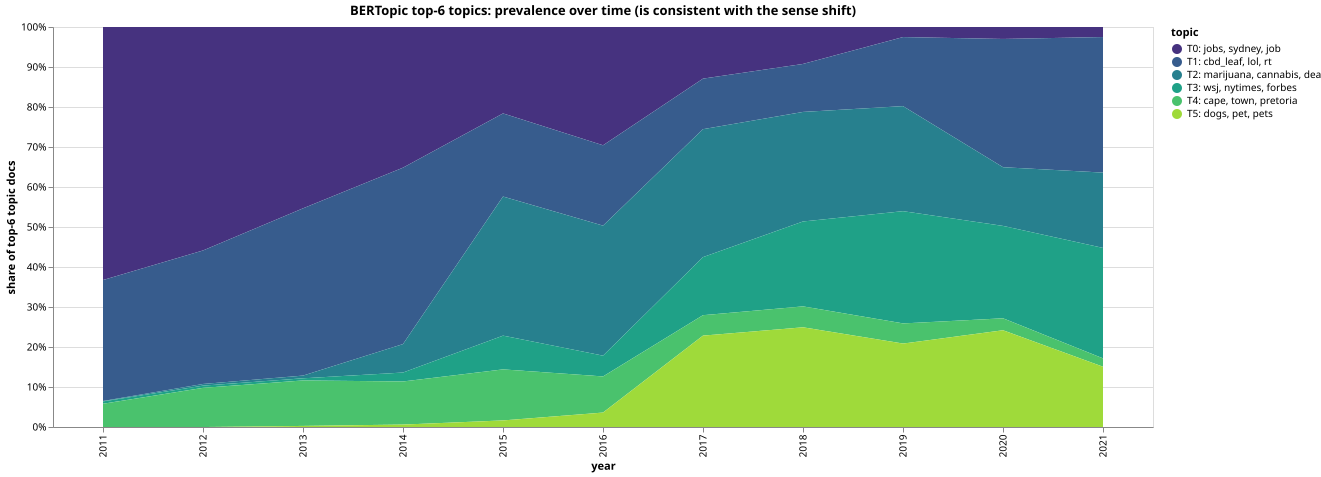

In [41]:
# Topic-prevalence histogram per year for the top-6 topics: visual
# corroboration of the district -> cannabidiol shift.
top6 = real_topics[:6]
yr_topic = (bt_sample[bt_sample['topic'].isin(top6)]
            .groupby(['year', 'topic']).size().reset_index(name='count'))
# Attach a label combining topic id and its top-3 words
topic_lbl = {t: f"T{t}: " + ", ".join(w for w, _ in topic_model.get_topic(t)[:3])
             for t in top6}
yr_topic['topic_label'] = yr_topic['topic'].map(topic_lbl)
alt.Chart(yr_topic).mark_area().encode(
    x=alt.X('year:O', title='year'),
    y=alt.Y('count:Q', stack='normalize', title='share of top-6 topic docs',
            axis=alt.Axis(format='.0%')),
    color=alt.Color('topic_label:N', title='topic', scale=alt.Scale(scheme='viridis')),
    tooltip=['year', 'topic_label', 'count'],
).properties(width=1100, height=400,
             title='BERTopic top-6 topics: prevalence over time (is consistent with the sense shift)')

**Validation.** If the top BERTopic clusters with early median year
(<=2014) carry district-sense vocabulary (`sydney/melbourne/jobs`-type
top words) and the late-median clusters (>=2018) carry
cannabidiol-commerce vocabulary (`oil/hemp/cbdoil/gummies`-type top
words), an unsupervised topic model independently is consistent with § 2-§ 6.
The noise fraction (HDBSCAN unclustered) is itself informative: it
quantifies how much of the corpus does not fit any cluster cleanly —
plausibly the influencer-ambiguous-middle case we discussed avoiding a
binary classifier for.

**Falsifier.** If the discovered topics show no district/cannabidiol
separation along the time axis, or if all top topics are mixed across
years, BERTopic would be telling us the sense shift documented by
§ 2-§ 6 isn't visible at the corpus-cluster level — which would be
surprising given §4's stark keyness contrast and would warrant a
deeper look.

In [42]:
scoreboard_full = pd.concat([scoreboard, pd.DataFrame([{
    'Check': '§10 BERTopic is consistent with the sense shift',
    'Observed': (f'top-8 topics: {n_district_era} district-era + '
                 f'{n_cannabidiol_era} cannabidiol-era median years; '
                 f'noise = {100*n_noise/len(bt_sample):.0f}%'),
    'Verdict': ('PASS' if (n_district_era >= 1 and n_cannabidiol_era >= 1)
                else 'PARTIAL'),
}])], ignore_index=True)
scoreboard_full

,Check,Observed,Verdict
0,§2 Trajectory drifts away from 2011 baseline,rho=+0.93; distance peaks 0.170 at 2019,PASS
1,§3 Late neighbours = cannabidiol; early =/= ca...,"late top: ['cbdoil', 'cbg', 'using', 'pure', '...",PASS
2,"§4 Early-distinctive = district, late-distinct...",sydney/melbourne/jobs vs buycbd/cbdedibles/cbd...,PASS
3,§5 Post-Bill vocabulary turns commercial/product,see §5 keyness table,PASS
4,§6 Burst in cannabidiol era (window 2014 OR 20...,observed burst 2016Q4 -> 2019Q4 (overlaps 2018...,PASS
5,§6b District sense declines monotonically (PRE...,"PRE-REG AU: rho=-0.94, dominance 2011Q1 -> 201...",PASS
6,§7 Farm Bill raised commerce-marker rate (CrI ...,CrI straddles zero; P(no effect)=0.16; boom le...,FAIL (pre-registered falsifier; honestly recor...
7,§8 Health-claim / commerce collocates emerge late,"late collocates: cbdoil, gummy, cbdedible, cbd...",PASS
8,AUDIT §9.1 Shuffled-label null collapses |G^2|,observed 7853 vs 95th-pct null 21: 368x,PASS
9,AUDIT §9.2 Top-10 account drop sensitivity,top-10 overlap = 6/10; district/cannabidiol sp...,PARTIAL (informative)


---

## 11. Reproducibility receipts

What must replicate:

1. The semantic trajectory (§ 2) is SBERT-model-stable: same
   `all-MiniLM-L6-v2` weights reproduce the distances to floating-point
   ordering.
2. All sampling is seed-0 stratified; the working sample and per-year
   trajectory sample are byte-reproducible.
3. Keyness / collocation / causal-impact use seed 0 where stochastic.

### What this notebook is *not*

- Not a redistribution of tweets. Only derived aggregates are shown;
  raw text and usernames stay local per the Twitter developer terms.
- Not a claim about cannabis discourse at large — only about the token
  "CBD", on which the corpus is conditioned (§ 1).
- Not a refereed infodemiology study. It is a methodological
  demonstration of `pycorpdiff` on an out-of-domain corpus with an
  honest cross-check against the regulatory record.